# Automatic Prompt Optimization Across Model Families
### A complete comparative analysis of six APO methods under one protocol

Prompt choice can move small-model accuracy by dozens of points, and a growing family of *automatic prompt optimization* (APO) methods competes to find those prompts. But published APO results are rarely comparable: different models, budgets, seeds, and harnesses. This study removes that noise. Six methods — our proposed **SWIFT** (curated fixed schedule) and **APEX** (UCB1 bandit scheduling), plus paper-faithful reimplementations of **CAPO, GAAPO, GEPA,** and **SEE** — run under a *single* protocol: same seeds, same seed prompts, same budget caps, same evaluation harness, each method keeping only its own paper-specific hyperparameters.

| Family | Models | Benchmarks |
|---|---|---|
| **3–4B** | Qwen3-4B-Instruct-2507, Llama-3.2-3B-Instruct | BBH (4 tasks) + GSM8K + HumanEval (Qwen3-4B) |
| **7–9B** | Llama-3.1-8B-Instruct, Gemma-7B-it, Qwen3-8B | BBH (4 tasks) |

Four research questions drive the analysis:

> **RQ1 — Outcome.** Which method is most accurate, and do the differences survive statistical scrutiny?
> **RQ2 — Cost.** What does each method's accuracy cost in LLM calls, tokens, and wall-clock time?
> **RQ3 — Mechanism.** *How* does each method search — which operators, what dynamics, what kind of prompts?
> **RQ4 — Generalization.** Do the answers transfer across models, families, and task types?

**The story in five parts:**

- **Part I · The experiment** (§1–3) — protocol, data provenance, and an honest inventory of what has actually run.
- **Part II · Outcomes** (§4–6) — headline accuracy, statistical reality-check, and the cost of every point *(RQ1, RQ2)*.
- **Part III · Mechanisms** (§7–10) — search dynamics, selection integrity, operator economics, and the evolution of the prompts themselves *(RQ3)*.
- **Part IV · The evidence up close** (§11–12) — per-instance agreement and verifier-style worked examples, down to the ancestry of individual winning prompts.
- **Part V · Synthesis** (§13–14) — cross-model generalization and conclusions *(RQ4)*.

Every figure and number regenerates from the raw run artifacts on disk — a `result_*.json` (scores, budget usage, per-generation history) and an `audit_*.json` (the full candidate genealogy: every generated prompt, its operator, parents, and scores) per run — so the notebook stays current as pending runs land.


---
# Part I · The Experiment

Before any comparison can be trusted, three things must be nailed down: the protocol every method ran under, where the numbers come from, and exactly which cells of the experiment matrix are complete. That is Part I's job.

## 1 · Protocol and conventions

Standard scientific stack only (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`) — no exotic dependencies, so the analysis reruns anywhere. Method colors and ordering are fixed **once** here; every figure in the notebook uses the same palette, so a method is visually the same entity everywhere.

In [1]:
import json
import math
import re
import warnings
from collections import defaultdict
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 115,
    "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "legend.fontsize": 10, "legend.title_fontsize": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.4,
    # Neutralize any globally-configured layout engine (e.g. constrained layout
    # in Jupyter configs): mixing it with colorbars + tight_layout raises.
    "figure.constrained_layout.use": False,
    "figure.autolayout": False,
})

def tl():
    """tight_layout that never crashes on layout-engine conflicts."""
    try:
        plt.tight_layout()
    except Exception:
        pass

def legend_right(ax, title=None):
    """Move an axes legend outside to the right — never covers data."""
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.02), frameon=False,
              title=title, borderaxespad=0)

def shared_top_legend(fig, axes_list, ncol=6, y=1.0):
    """One figure-level legend on top; removes duplicated per-axes legends."""
    h, l = axes_list[0].get_legend_handles_labels()
    for ax in axes_list:
        lg = ax.get_legend()
        if lg is not None:
            lg.remove()
    fig.legend(h, l, ncol=ncol, loc="lower center",
               bbox_to_anchor=(0.5, y), frameon=False)

OUTPUTS = Path("..") / "outputs"

METHODS = ["swift", "apex", "capo", "gaapo", "gepa", "see"]
METHOD_LABEL = {"swift": "SWIFT", "apex": "APEX", "capo": "CAPO",
                "gaapo": "GAAPO", "gepa": "GEPA", "see": "SEE"}
PALETTE = dict(zip(METHODS, sns.color_palette("colorblind", len(METHODS))))
LPALETTE = {METHOD_LABEL[m]: c for m, c in PALETTE.items()}

MODEL_META = {  # dir-slug -> (display, family, params in B)
    "qwen3-4b":               ("Qwen3-4B",     "3-4B", 4.0),
    "llama-3.2-3b-instruct":  ("Llama-3.2-3B", "3-4B", 3.2),
    "llama-3.1-8b-instruct":  ("Llama-3.1-8B", "7-9B", 8.0),
    "gemma-7b-it":            ("Gemma-7B",     "7-9B", 7.0),
    "qwen3-8b":               ("Qwen3-8B",     "7-9B", 8.0),
}
FAMILY_ORDER = ["3-4B", "7-9B"]
MODEL_ORDER = ["Qwen3-4B", "Llama-3.2-3B", "Llama-3.1-8B", "Gemma-7B", "Qwen3-8B"]

# (source dir, flat model slug or None for <model>/<method>/<task>/<seed> layout)
SOURCES = [
    (OUTPUTS / "proposal_comparison_3bench_qwen3-4-instruct", "qwen3-4b"),
    (OUTPUTS / "multi_model_cot_4bs", None),
    (OUTPUTS / "multi_model_cot_8bs", None),
]

BBH_TASKS = ["bbh_causal_judgement", "bbh_disambiguation_qa",
             "bbh_formal_fallacies", "bbh_hyperbaton"]
TASK_SHORT = {"bbh_causal_judgement": "CJ", "bbh_disambiguation_qa": "DQ",
              "bbh_formal_fallacies": "FF", "bbh_hyperbaton": "HY",
              "gsm8k": "GSM8K", "humaneval": "HumanEval"}

def benchmark_of(task):
    return "bbh" if task.startswith("bbh_") else task

## 2 · Data provenance

Every run on disk becomes rows in three dataframes, at three levels of granularity:

- **`runs`** — one row per (model, method, task, seed): final scores, budget usage, timing. *Powers Parts II and V.*
- **`traj`** — one row per optimization generation: best/mean dev score, population size, operator counts, wall-clock timestamp. *Powers the search-dynamics analyses in Part III.*
- **`cand`** — one row per *generated candidate*, from the audit genealogy: operator, parent, dev/minibatch score, full prompt text. *Powers the operator economics, prompt-evolution, and ancestry analyses in Parts III–IV.*

Loading is defensive: malformed or missing files are collected into `load_errors` instead of crashing, so a partially-synced results directory never blocks the analysis.

In [2]:
run_rows, traj_rows, cand_rows, load_errors = [], [], [], []
per_sample = {}   # (model, method, task, seed) -> test_per_sample_details
best_prompts = {} # (model, method, task, seed) -> best prompt text
seed_prompts = {} # (model, task) -> seed prompt (truncated in config, still useful)

for src, flat_slug in SOURCES:
    if not src.exists():
        continue
    for f in sorted(src.rglob("result_*.json")):
        rel = f.relative_to(src).parts
        try:
            if flat_slug and len(rel) == 4:
                slug, method, task, seed_dir = flat_slug, rel[0], rel[1], rel[2]
            elif len(rel) == 5:
                slug, method, task, seed_dir = rel[0], rel[1], rel[2], rel[3]
            else:
                continue
            if method not in METHODS:
                continue
            model, family, params = MODEL_META.get(slug, (slug, "?", np.nan))
            seed = int(seed_dir.replace("seed_", ""))
            d = json.loads(f.read_text(encoding="utf-8"))
            u = d.get("llm_usage", {}) or {}
            run_rows.append(dict(
                model=model, family=family, params_b=params,
                method=method, task=task, benchmark=benchmark_of(task), seed=seed,
                test_score=d.get("test_score"), best_dev=d.get("best_score"),
                iterations=d.get("num_iterations"),
                calls=u.get("total_calls"), tokens_in=u.get("total_input_tokens"),
                tokens_out=u.get("total_output_tokens"), tokens=u.get("total_tokens"),
                llm_time=u.get("total_time_seconds"), total_time=d.get("total_time"),
            ))
            key = (model, method, task, seed)
            best_prompts[key] = d.get("best_prompt") or ""
            sp = (d.get("config") or {}).get("seed_prompt")
            if sp:
                seed_prompts.setdefault((model, task), sp)
            tpd = d.get("test_per_sample_details")
            if tpd:
                per_sample[key] = tpd
            for h in d.get("optimization_history") or []:
                traj_rows.append(dict(
                    model=model, family=family, method=method, task=task,
                    benchmark=benchmark_of(task), seed=seed,
                    generation=h.get("generation"), best_score=h.get("best_score"),
                    mean_score=h.get("mean_score"), pop=h.get("population_size"),
                    operator_counts=h.get("operator_counts") or {},
                    best_record_id=h.get("best_record_id"),
                    timestamp=h.get("timestamp"),
                ))
            audits = list(f.parent.glob("audit_*.json"))
            if audits:
                a = json.loads(audits[0].read_text(encoding="utf-8"))
                recs = (a.get("history") or {}).get("records") or {}
                by_id = {rid: r for rid, r in recs.items()}
                for rid, r in recs.items():
                    scores = r.get("scores") or {}
                    parents = r.get("parent_ids") or []
                    pdev = None
                    if parents and parents[0] in by_id:
                        pdev = (by_id[parents[0]].get("scores") or {}).get("dev")
                    ptext = by_id[parents[0]].get("text", "") if parents and parents[0] in by_id else ""
                    cand_rows.append(dict(
                        model=model, family=family, method=method, task=task,
                        benchmark=benchmark_of(task), seed=seed, rid=rid,
                        operator=r.get("operator"), n_parents=len(parents),
                        parent0=parents[0] if parents else None,
                        generation=r.get("generation_created"),
                        dev=scores.get("dev"), minibatch=scores.get("minibatch"),
                        parent_dev=pdev, text=r.get("text") or "", parent_text=ptext,
                        is_complete=bool(r.get("is_complete")),
                    ))
        except Exception as e:
            load_errors.append((str(f), repr(e)))

runs = pd.DataFrame(run_rows)
traj = pd.DataFrame(traj_rows)
cand = pd.DataFrame(cand_rows)
for df in (runs, traj, cand):
    if not df.empty:
        df["Method"] = df["method"].map(METHOD_LABEL)

print(f"runs: {len(runs)}   traj rows: {len(traj)}   candidates: {len(cand)}   load errors: {len(load_errors)}")
if load_errors:
    for f_, e_ in load_errors[:5]:
        print("  !", f_, e_)

runs: 370   traj rows: 1670   candidates: 13244   load errors: 0


## 3 · Coverage: what actually ran

**Question: which cells of the (model × method × task × seed) matrix are complete?** The experiment is still growing — a few runs (e.g., GEPA on the 3–4B models, Qwen3-8B) may still be pending — so this section is the notebook's honesty ledger. Each heatmap cell shows completed seeds out of the 3 expected. Everything downstream keys off this: statistics that need balanced blocks use only complete cells, and nothing incomplete is ever silently averaged in.

**How to read it:** dark green columns = fully-run; pale/empty cells = pending. The printout below the figure names exactly which methods are BBH-complete per model — that list defines who is eligible for the macro tables (§4) and the significance tests (§5).

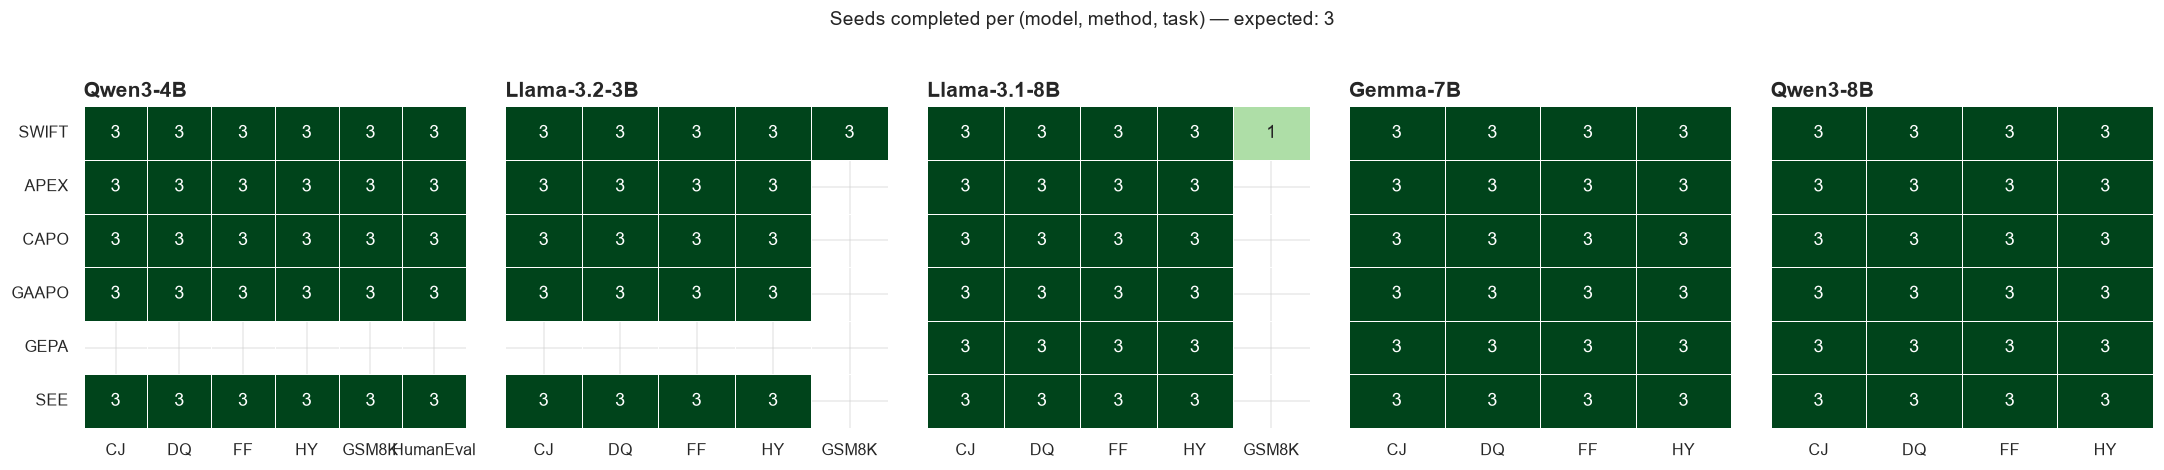

Qwen3-4B       BBH-complete: ['SWIFT', 'APEX', 'CAPO', 'GAAPO', 'SEE']   (incomplete: ['GEPA'])
Llama-3.2-3B   BBH-complete: ['SWIFT', 'APEX', 'CAPO', 'GAAPO', 'SEE']   (incomplete: ['GEPA'])
Llama-3.1-8B   BBH-complete: ['SWIFT', 'APEX', 'CAPO', 'GAAPO', 'GEPA', 'SEE']
Gemma-7B       BBH-complete: ['SWIFT', 'APEX', 'CAPO', 'GAAPO', 'GEPA', 'SEE']
Qwen3-8B       BBH-complete: ['SWIFT', 'APEX', 'CAPO', 'GAAPO', 'GEPA', 'SEE']


In [3]:
exp_seeds = 3
cov = (runs.groupby(["model", "Method", "task"])["seed"].nunique()
           .rename("seeds").reset_index())
models_present = [m for m in MODEL_ORDER if m in runs.model.unique()]

fig, axes = plt.subplots(1, max(len(models_present), 1),
                         figsize=(3.8 * len(models_present), 4), squeeze=False)
for i, (ax, model) in enumerate(zip(axes[0], models_present)):
    sub = cov[cov.model == model]
    tasks_here = [t for t in BBH_TASKS + ["gsm8k", "humaneval"] if t in sub.task.unique()]
    grid = (sub.pivot_table(index="Method", columns="task", values="seeds", aggfunc="sum")
                .reindex(index=[METHOD_LABEL[m] for m in METHODS], columns=tasks_here))
    sns.heatmap(grid, ax=ax, annot=True, fmt=".0f", cmap="Greens",
                vmin=0, vmax=exp_seeds, cbar=False, linewidths=.6,
                annot_kws={"fontsize": 11})
    ax.set_title(model, loc="left"); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticklabels([TASK_SHORT.get(t, t) for t in tasks_here],
                       rotation=0, fontsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=10)
    if i > 0:
        ax.set_yticklabels([])
fig.suptitle("Seeds completed per (model, method, task) — expected: 3",
             y=1.02, fontsize=12)
tl(); plt.show()

complete_bbh = {}
for model in models_present:
    ok = []
    for m in METHODS:
        s = cov[(cov.model == model) & (cov.Method == METHOD_LABEL[m]) &
                (cov.task.isin(BBH_TASKS)) & (cov.seeds >= exp_seeds)]
        if len(s) == len(BBH_TASKS):
            ok.append(m)
    complete_bbh[model] = ok
    missing = [METHOD_LABEL[m] for m in METHODS if m not in ok]
    print(f"{model:14s} BBH-complete: {[METHOD_LABEL[m] for m in ok]}"
          + (f"   (incomplete: {missing})" if missing else ""))

---
# Part II · Outcomes — who wins, is it real, and at what price?

*(RQ1, RQ2)* This part delivers the numbers a reader would quote: accuracy per task and model (§4), whether the gaps between methods survive statistical scrutiny (§5), and the compute bill behind each score (§6).

## 4 · Headline accuracy

**Question: which method scores highest, where?** Task-level bars show the mean over seeds with each individual seed as a dot — with only three seeds, showing the raw points is more honest than error bars alone. The **BBH macro** (mean of the four tasks, computed per seed and then aggregated) is the single number used for rankings throughout; only BBH-complete methods enter it.

**How to read it:** look for two things — the *ordering* of bars within a task, and the *spread* of the seed dots. Where dots overlap heavily between methods, §5 will confirm the difference isn't real.

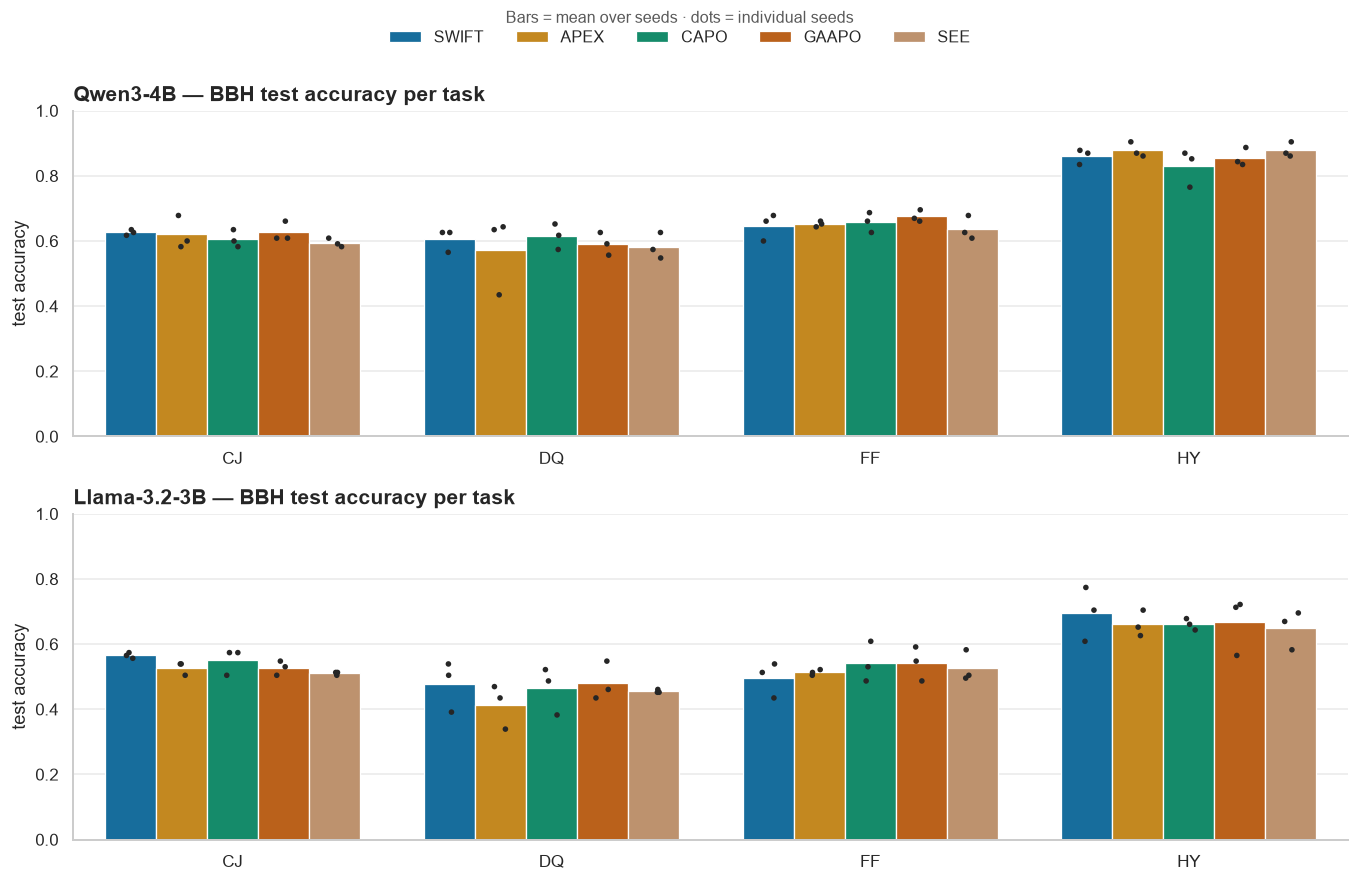

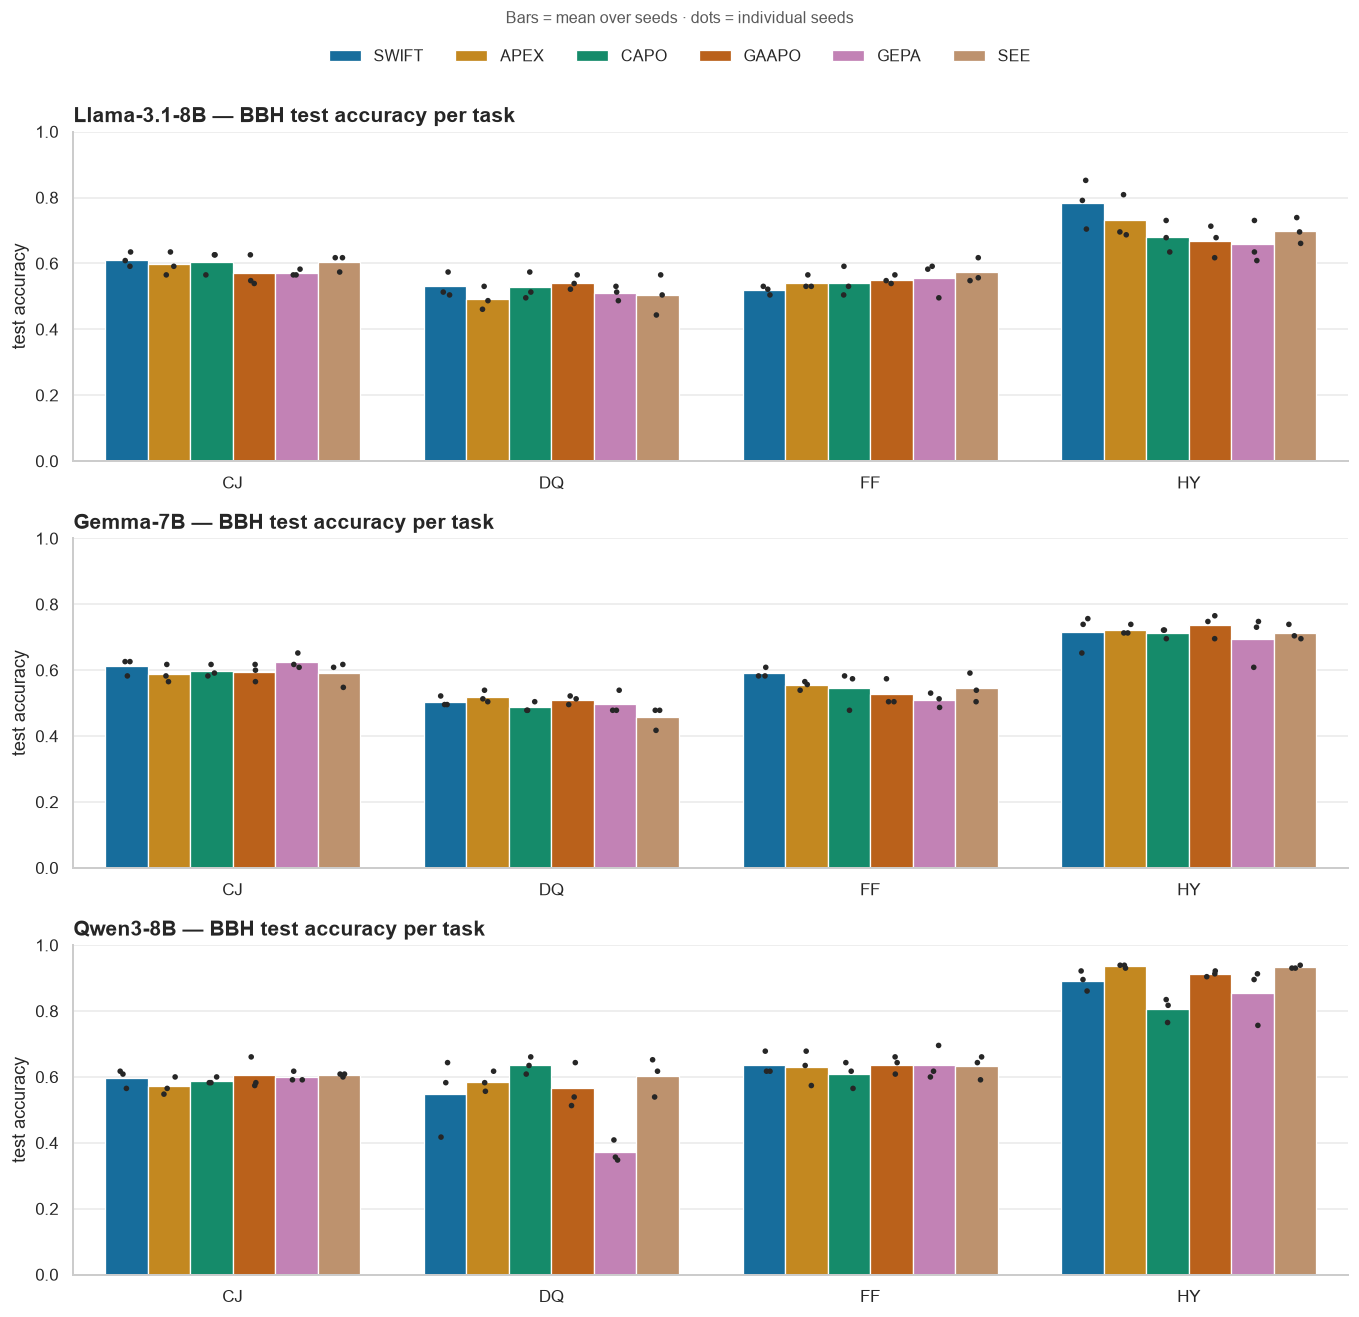

In [4]:
for family in FAMILY_ORDER:
    fmodels = [m for m in models_present if runs[(runs.model == m)].family.iloc[0] == family]
    if not fmodels:
        continue
    fig, axes = plt.subplots(len(fmodels), 1, figsize=(12, 3.6 * len(fmodels)),
                             squeeze=False, sharex=False)
    plotted = []
    for ax, model in zip(axes[:, 0], fmodels):
        sub = runs[(runs.model == model) & (runs.benchmark == "bbh")].copy()
        if sub.empty:
            continue
        sub["Task"] = sub.task.map(TASK_SHORT)
        torder = [TASK_SHORT[t] for t in BBH_TASKS if TASK_SHORT[t] in sub.Task.unique()]
        order = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in sub.Method.unique()]
        sns.barplot(data=sub, x="Task", y="test_score", hue="Method",
                    order=torder, hue_order=order, palette=LPALETTE,
                    errorbar=None, ax=ax, edgecolor="white", linewidth=0.8)
        sns.stripplot(data=sub, x="Task", y="test_score", hue="Method",
                      order=torder, hue_order=order, dodge=True, ax=ax,
                      color="0.15", size=3.5, jitter=0.12, legend=False)
        ax.set_title(f"{model} — BBH test accuracy per task", loc="left")
        ax.set_xlabel(""); ax.set_ylabel("test accuracy")
        ax.set_ylim(0, 1.0); ax.tick_params(axis="x", rotation=0)
        plotted.append(ax)
    if plotted:
        shared_top_legend(fig, plotted, ncol=6, y=1.005)
        fig.text(0.5, 1.05, "Bars = mean over seeds · dots = individual seeds",
                 ha="center", fontsize=10, color="0.35")
    tl(); plt.show()

In [5]:
def bbh_macro_per_seed(df):
    rows = []
    for (model, method, seed), g in df[df.benchmark == "bbh"].groupby(["model", "method", "seed"]):
        if set(g.task) >= set(BBH_TASKS):
            rows.append(dict(model=model, method=method, seed=seed,
                             macro=g.set_index("task").loc[BBH_TASKS, "test_score"].mean()))
    return pd.DataFrame(rows)

macro = bbh_macro_per_seed(runs)
tbl = (macro.groupby(["model", "method"])["macro"]
            .agg(mean="mean", std="std", n="count").reset_index())
tbl["Method"] = tbl.method.map(METHOD_LABEL)
pivot_mean = (tbl.pivot(index="Method", columns="model", values="mean")
                 .reindex([METHOD_LABEL[m] for m in METHODS])
                 [[m for m in MODEL_ORDER if m in tbl.model.unique()]])
display(pivot_mean.round(3).style.background_gradient(cmap="RdYlGn", axis=0)
        .format("{:.3f}", na_rep="—").set_caption(
        "BBH macro accuracy (mean over seeds). Blank = incomplete data."))

print("\nmean ± std (n seeds):")
for model in [m for m in MODEL_ORDER if m in tbl.model.unique()]:
    s = tbl[tbl.model == model].sort_values("mean", ascending=False)
    print(f"\n{model}")
    for _, r in s.iterrows():
        print(f"   {r.Method:6s} {r['mean']:.3f} ± {0 if np.isnan(r['std']) else r['std']:.3f} (n={int(r.n)})")

model,Qwen3-4B,Llama-3.2-3B,Llama-3.1-8B,Gemma-7B,Qwen3-8B
Method,,,,,
SWIFT,0.685,0.559,0.611,0.606,0.669
APEX,0.680,0.529,0.591,0.596,0.680
CAPO,0.677,0.554,0.589,0.586,0.659
GAAPO,0.687,0.554,0.583,0.592,0.680
GEPA,—,—,0.574,0.583,0.616
SEE,0.673,0.536,0.595,0.577,0.693



mean ± std (n seeds):

Qwen3-4B
   GAAPO  0.687 ± 0.017 (n=3)
   SWIFT  0.685 ± 0.011 (n=3)
   APEX   0.680 ± 0.041 (n=3)
   CAPO   0.677 ± 0.035 (n=3)
   SEE    0.673 ± 0.014 (n=3)

Llama-3.2-3B
   SWIFT  0.559 ± 0.033 (n=3)
   GAAPO  0.554 ± 0.044 (n=3)
   CAPO   0.554 ± 0.040 (n=3)
   SEE    0.536 ± 0.027 (n=3)
   APEX   0.529 ± 0.025 (n=3)

Llama-3.1-8B
   SWIFT  0.611 ± 0.008 (n=3)
   SEE    0.595 ± 0.033 (n=3)
   APEX   0.591 ± 0.003 (n=3)
   CAPO   0.589 ± 0.015 (n=3)
   GAAPO  0.583 ± 0.018 (n=3)
   GEPA   0.574 ± 0.024 (n=3)

Gemma-7B
   SWIFT  0.606 ± 0.025 (n=3)
   APEX   0.596 ± 0.012 (n=3)
   GAAPO  0.592 ± 0.003 (n=3)
   CAPO   0.586 ± 0.012 (n=3)
   GEPA   0.583 ± 0.013 (n=3)
   SEE    0.577 ± 0.005 (n=3)

Qwen3-8B
   SEE    0.693 ± 0.015 (n=3)
   GAAPO  0.680 ± 0.037 (n=3)
   APEX   0.680 ± 0.024 (n=3)
   SWIFT  0.669 ± 0.033 (n=3)
   CAPO   0.659 ± 0.014 (n=3)
   GEPA   0.616 ± 0.040 (n=3)


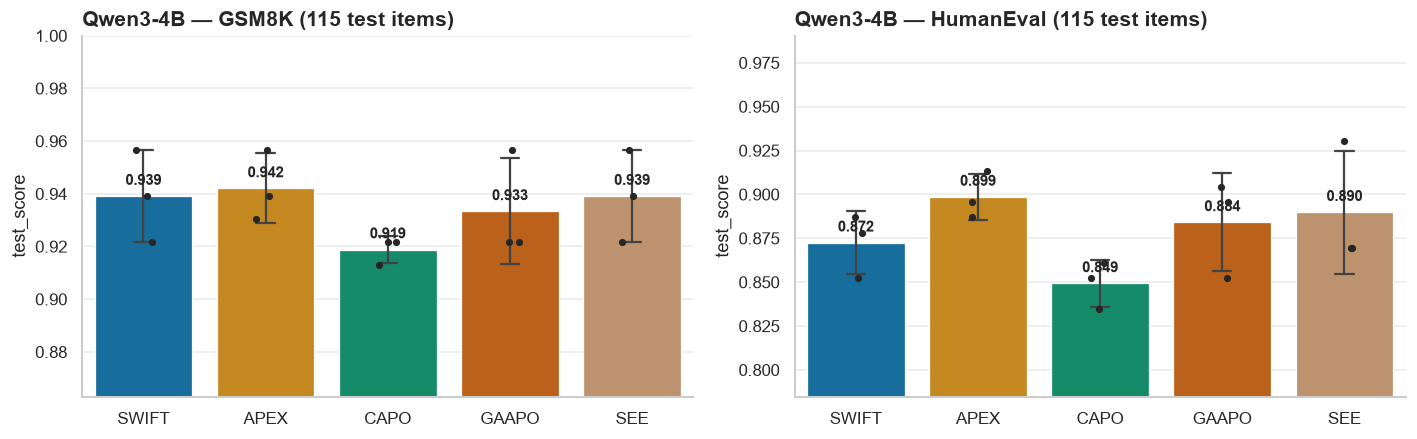

In [6]:
gh = runs[(runs.model == "Qwen3-4B") & (runs.benchmark.isin(["gsm8k", "humaneval"]))]
if not gh.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
    for ax, bench in zip(axes, ["gsm8k", "humaneval"]):
        sub = gh[gh.benchmark == bench]
        order = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in sub.Method.unique()]
        sns.barplot(data=sub, x="Method", y="test_score", order=order,
                    palette=LPALETTE, errorbar="sd", ax=ax,
                    edgecolor="white", linewidth=0.8,
                    err_kws={"linewidth": 1.4}, capsize=0.15)
        means = sub.groupby("Method").test_score.mean()
        for i, m in enumerate(order):
            ax.annotate(f"{means[m]:.3f}", (i, means[m]),
                        xytext=(0, 7), textcoords="offset points",
                        ha="center", fontsize=9.5, fontweight="bold")
        sns.stripplot(data=sub, x="Method", y="test_score", order=order,
                      ax=ax, color="0.15", size=4.5, jitter=0.08)
        lo = max(0, sub.test_score.min() - 0.05)
        ax.set_ylim(lo, min(1.0, sub.test_score.max() + 0.06))
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
        ax.set_title(f"Qwen3-4B — {TASK_SHORT[bench]} (115 test items)", loc="left")
    tl(); plt.show()
else:
    print("No GSM8K/HumanEval runs found for Qwen3-4B.")

**Capability profile (radar).** The model-report-style view: one polygon per method over every benchmark task, exposing *shape* differences (e.g., a method that wins math but loses code) that averages hide. Axes are min–max scaled per task so the plot spreads over the informative range; the grey band marks each axis's observed range.

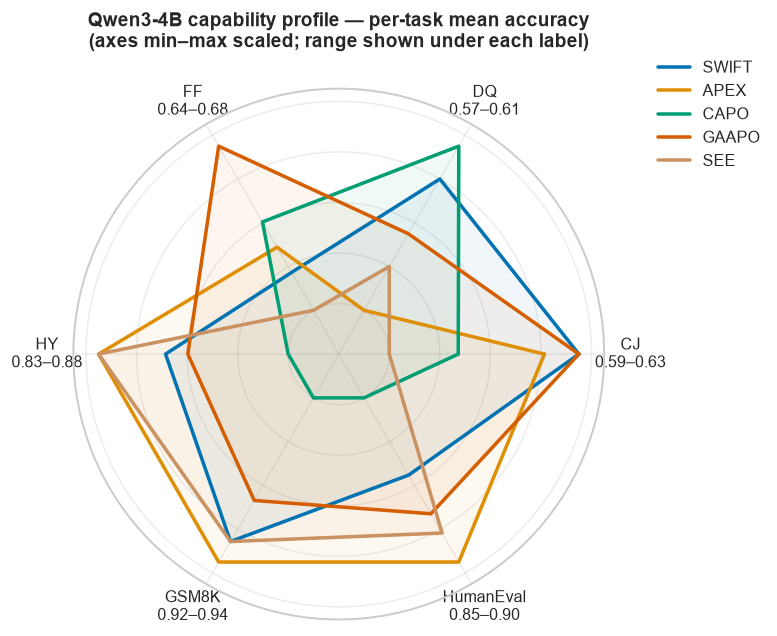

In [7]:
prof = (runs[runs.model == "Qwen3-4B"]
        .groupby(["Method", "task"]).test_score.mean().unstack())
tasks6 = [t for t in BBH_TASKS + ["gsm8k", "humaneval"] if t in prof.columns]
prof = prof[tasks6].dropna()
if len(prof) >= 2:
    lo, hi = prof.min(), prof.max()
    span = (hi - lo).replace(0, 1e-9)
    norm = (prof - lo) / span * 0.75 + 0.2   # keep polygons off the center
    n = len(tasks6)
    ang = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    fig, ax = plt.subplots(figsize=(7.2, 7.2), subplot_kw=dict(polar=True))
    for meth in [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in norm.index]:
        vals = norm.loc[meth].tolist()
        ax.plot(ang + ang[:1], vals + vals[:1], lw=2.2, label=meth,
                color=LPALETTE[meth])
        ax.fill(ang + ang[:1], vals + vals[:1], color=LPALETTE[meth], alpha=0.06)
    ax.set_xticks(ang)
    ax.set_xticklabels([f"{TASK_SHORT.get(t, t)}\n{lo[t]:.2f}–{hi[t]:.2f}"
                        for t in tasks6], fontsize=10)
    ax.set_yticklabels([]); ax.set_ylim(0, 1.05); ax.grid(alpha=0.35)
    ax.set_title("Qwen3-4B capability profile — per-task mean accuracy\n"
                 "(axes min–max scaled; range shown under each label)",
                 pad=26, fontsize=12)
    ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.08), frameon=False)
    tl(); plt.show()

## 5 · Are the differences real? (Demšar protocol)

**Question: do the accuracy gaps in §4 survive statistical scrutiny?** With few seeds and several (model, task) conditions, the standard machinery for comparing $k$ algorithms over $N$ datasets is:

1. **Friedman test** on per-block ranks (non-parametric; no normality assumption — appropriate for our N < 30 blocks). Blocks are (model, task) pairs; the block score is the mean over seeds.
2. If Friedman rejects, **Nemenyi post-hoc**: two methods differ significantly when their average ranks differ by more than the critical difference $CD = q_\alpha \sqrt{k(k+1)/(6N)}$.
3. The **critical-difference diagram** puts methods on a rank axis and connects groups that are *not* significantly different — the single most information-dense figure in comparative benchmarking.

Two configurations are run: **(A)** all six methods over the blocks where all six are complete, and **(B)** the five long-complete methods over every complete block (more blocks → more statistical power). Only balanced blocks enter either test.

**How to read it:** in the CD diagram, being leftmost is good, but any methods joined by a thick bar are statistically indistinguishable at α=0.05. A leader that no bar separates from the pack is a *tendency*, not a proven superiority — the paper's claims are phrased accordingly.

In [8]:
def friedman_blocks(df, methods):
    labels = [METHOD_LABEL[m] for m in methods]
    blocks, names = [], []
    for (model, task), g in df[df.benchmark == "bbh"].groupby(["model", "task"]):
        m = g.groupby("Method")["test_score"].agg(["mean", "count"])
        if set(labels) <= set(m.index) and (m.loc[labels, "count"] >= exp_seeds).all():
            blocks.append(m.loc[labels, "mean"].values)
            names.append(f"{model}/{TASK_SHORT.get(task, task)}")
    return np.array(blocks), names, labels

# Two views: (A) all six methods over the blocks where all six are complete;
# (B) the five long-complete methods over every complete block (more power).
configs = {}
for name, mset in [("A: all 6 methods", [*METHODS]),
                   ("B: without GEPA", [m for m in METHODS if m != "gepa"])]:
    Xc, bn, lb = friedman_blocks(runs, mset)
    if len(Xc) >= 3:
        st, pv = stats.friedmanchisquare(*Xc.T)
        rk = pd.DataFrame([stats.rankdata(-row) for row in Xc], columns=lb, index=bn)
        configs[name] = dict(X=Xc, names=bn, labels=lb, stat=st, p=pv,
                             ranks=rk, avg=rk.mean().sort_values())
        print(f"[{name}]  k={len(lb)}, N={len(Xc)} blocks "
              f"-> Friedman chi2={st:.3f}, p={pv:.4f}"
              + ("  (significant)" if pv < 0.05 else "  (not significant)"))
        print("   avg ranks:", ", ".join(f"{m} {r:.2f}" for m, r in
                                          configs[name]["avg"].items()))
    else:
        print(f"[{name}] not enough complete blocks yet.")

# the CD diagram below uses the configuration with the most blocks (most power)
best_cfg = max(configs.values(), key=lambda c: len(c["X"])) if configs else None
if best_cfg:
    X, block_names, labels = best_cfg["X"], best_cfg["names"], best_cfg["labels"]
    p, ranks, avg_rank = best_cfg["p"], best_cfg["ranks"], best_cfg["avg"]
    print(f"\nCD diagram uses: k={len(labels)}, N={len(X)} blocks -> {block_names}")

[A: all 6 methods]  k=6, N=12 blocks -> Friedman chi2=4.636, p=0.4619  (not significant)
   avg ranks: SWIFT 2.83, GAAPO 3.12, SEE 3.33, APEX 3.54, CAPO 3.96, GEPA 4.21
[B: without GEPA]  k=5, N=20 blocks -> Friedman chi2=5.517, p=0.2383  (not significant)
   avg ranks: SWIFT 2.50, GAAPO 2.62, CAPO 3.17, APEX 3.27, SEE 3.42

CD diagram uses: k=5, N=20 blocks -> ['Gemma-7B/CJ', 'Gemma-7B/DQ', 'Gemma-7B/FF', 'Gemma-7B/HY', 'Llama-3.1-8B/CJ', 'Llama-3.1-8B/DQ', 'Llama-3.1-8B/FF', 'Llama-3.1-8B/HY', 'Llama-3.2-3B/CJ', 'Llama-3.2-3B/DQ', 'Llama-3.2-3B/FF', 'Llama-3.2-3B/HY', 'Qwen3-4B/CJ', 'Qwen3-4B/DQ', 'Qwen3-4B/FF', 'Qwen3-4B/HY', 'Qwen3-8B/CJ', 'Qwen3-8B/DQ', 'Qwen3-8B/FF', 'Qwen3-8B/HY']


k=5, N=20, CD(0.05) = 1.364


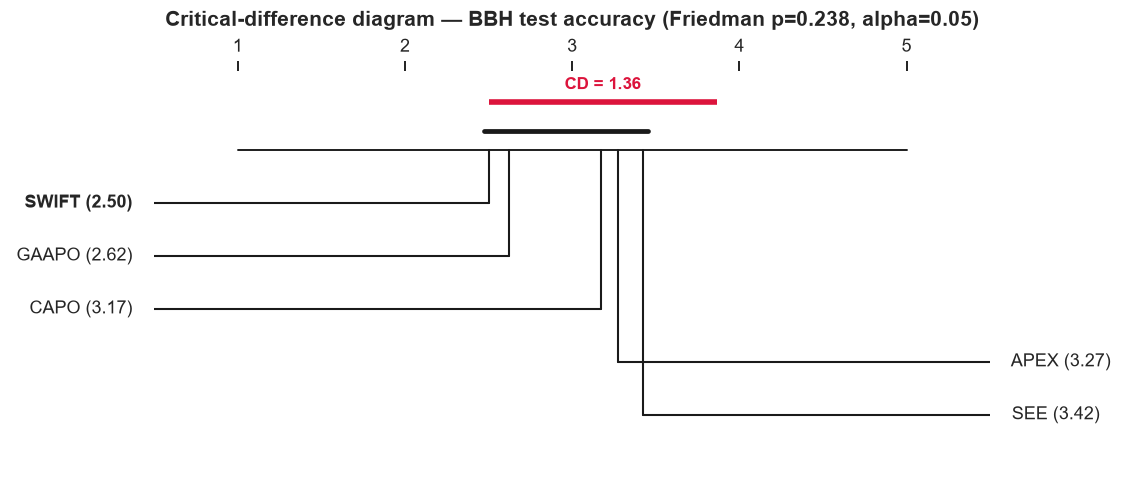


Win/Tie/Loss (row vs column, over blocks):


,SWIFT,APEX,CAPO,GAAPO,SEE
SWIFT,—,12/0/8,15/0/5,8/2/10,14/0/6
APEX,8/0/12,—,9/1/10,7/1/12,9/1/10
CAPO,5/0/15,10/1/9,—,8/0/12,12/2/6
GAAPO,10/2/8,12/1/7,12/0/8,—,12/0/8
SEE,6/0/14,10/1/9,6/2/12,8/0/12,—


In [9]:
# Nemenyi critical difference + CD diagram (Demsar 2006)
Q05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031}
if configs:
    k, N = len(labels), len(X)
    cd = Q05[k] * math.sqrt(k * (k + 1) / (6 * N))
    print(f"k={k}, N={N}, CD(0.05) = {cd:.3f}")

    r = avg_rank  # sorted ascending (best first)
    fig, ax = plt.subplots(figsize=(10, 2.6 + 0.35 * k))
    ax.set_xlim(0.5, k + 0.5); ax.set_ylim(0, k + 2.5)
    ax.spines[["left", "right", "bottom"]].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.xaxis.tick_top(); ax.set_xlabel(""); ax.grid(False)
    ax.set_xticks(np.arange(1, k + 1))
    ax.tick_params(labelsize=11)
    # method lines
    ys = {}
    for i, (name, rk) in enumerate(r.items()):
        y = k - i
        side = "left" if i < math.ceil(k / 2) else "right"
        tx = 0.4 if side == "left" else k + 0.6
        ha = "right" if side == "left" else "left"
        ax.plot([rk, rk], [k + 1, y], c="k", lw=1.3)
        ax.plot([rk, tx], [y, y], c="k", lw=1.3)
        ax.text(tx, y, f" {name} ({rk:.2f}) ", ha=ha, va="center",
                fontsize=11.5, fontweight="bold" if i == 0 else "normal")
        ys[name] = y
    ax.plot([r.min(), r.min() + cd], [k + 1.9, k + 1.9], c="crimson", lw=3.5,
            solid_capstyle="butt")
    ax.text(r.min() + cd / 2, k + 2.15, f"CD = {cd:.2f}", ha="center",
            color="crimson", fontsize=10.5, fontweight="bold")
    # connect non-significant groups
    yy = k + 1.35
    drawn = []
    for i in range(k):
        lo = r.iloc[i]
        grp = [j for j in range(k) if abs(r.iloc[j] - lo) <= cd and j >= i]
        if len(grp) > 1 and not any(set(grp) <= set(g) for g in drawn):
            drawn.append(grp)
            ax.plot([r.iloc[grp[0]] - 0.03, r.iloc[grp[-1]] + 0.03], [yy, yy],
                    c="k", lw=3, solid_capstyle="round")
            yy -= 0.35
    ax.plot([1, k], [k + 1, k + 1], c="k", lw=1.2)
    ax.set_title("Critical-difference diagram — BBH test accuracy "
                 f"(Friedman p={p:.3f}, alpha=0.05)", pad=28)
    tl(); plt.show()

    # pairwise win/tie/loss over blocks
    wtl = pd.DataFrame(index=labels, columns=labels, dtype=object)
    for a in labels:
        for b in labels:
            if a == b: wtl.loc[a, b] = "—"; continue
            d = ranks[a] - ranks[b]
            wtl.loc[a, b] = f"{(d < 0).sum()}/{(d == 0).sum()}/{(d > 0).sum()}"
    print("\nWin/Tie/Loss (row vs column, over blocks):")
    display(wtl)

**Pairwise Wilcoxon signed-rank tests (Holm-corrected).** The Nemenyi test is conservative; the standard complement is a per-pair Wilcoxon signed-rank over the same blocks with Holm's step-down correction for the multiple comparisons. Cells show adjusted p-values; green cells clear 0.05.

**Seed stability.** A direct visualization of run-to-run variance — the standard deviation of the BBH macro across seeds, per method and model. This is the quantitative backing for any "method X is the most stable" claim.

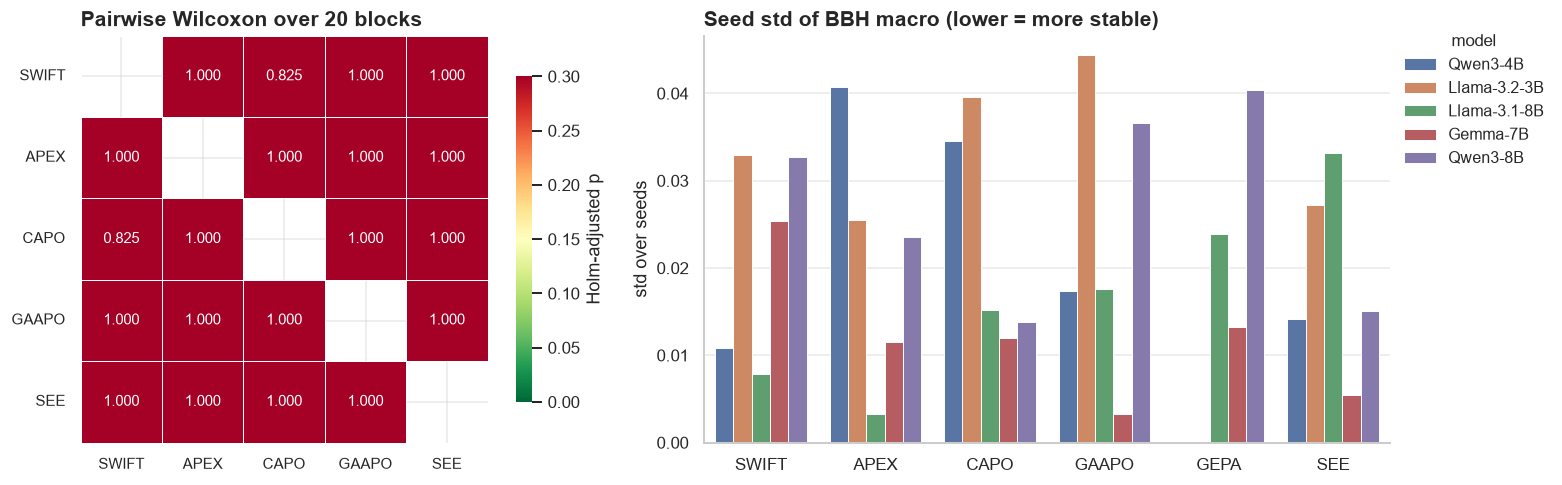

Significant pairs at 0.05 (Holm): none


In [10]:
if configs:
    k = len(labels)
    pairs = [(a, b) for ai, a in enumerate(labels) for b in labels[ai + 1:]]
    praw = {}
    for a, b in pairs:
        ia, ib = labels.index(a), labels.index(b)
        try:
            praw[(a, b)] = stats.wilcoxon(X[:, ia], X[:, ib]).pvalue
        except ValueError:
            praw[(a, b)] = 1.0
    # Holm step-down
    items = sorted(praw.items(), key=lambda kv: kv[1])
    m_ = len(items)
    padj, running = {}, 0.0
    for r_, ((a, b), pv) in enumerate(items):
        running = max(running, min(1.0, (m_ - r_) * pv))
        padj[(a, b)] = running
    P = pd.DataFrame(np.nan, index=labels, columns=labels)
    for (a, b), v in padj.items():
        P.loc[a, b] = P.loc[b, a] = v
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), width_ratios=[1, 1.2])
    sns.heatmap(P, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.3,
                ax=axes[0], square=True, linewidths=0.5,
                annot_kws={"fontsize": 9.5},
                cbar_kws={"label": "Holm-adjusted p", "shrink": 0.8})
    axes[0].set_title(f"Pairwise Wilcoxon over {len(X)} blocks", loc="left")
    axes[0].tick_params(axis="x", rotation=0, labelsize=9.5)
    axes[0].tick_params(axis="y", rotation=0, labelsize=9.5)

    stab = tbl.dropna(subset=["std"]).copy()
    sorder = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in stab.Method.unique()]
    sns.barplot(data=stab, x="Method", y="std", order=sorder, hue="model",
                hue_order=[m for m in MODEL_ORDER if m in stab.model.unique()],
                ax=axes[1], edgecolor="white", linewidth=0.6)
    axes[1].set_title("Seed std of BBH macro (lower = more stable)", loc="left")
    axes[1].set_xlabel(""); axes[1].set_ylabel("std over seeds")
    axes[1].tick_params(axis="x", rotation=0)
    legend_right(axes[1], title="model")
    tl(); plt.show()
    sig = [(a, b, v) for (a, b), v in padj.items() if v < 0.05]
    print("Significant pairs at 0.05 (Holm):",
          [f"{a} vs {b} (p={v:.3f})" for a, b, v in sig] or "none")

## 6 · What does each point of accuracy cost?

**Question: are the accuracy differences of §4–5 bought with proportional compute, or do some methods get more per call?** The centerpiece is the **cost–accuracy Pareto frontier**: a method is Pareto-optimal when no other method is simultaneously more accurate *and* cheaper. The bar panels break the bill down into LLM calls, tokens, and wall-clock, and the input/output token split shows *where* each method spends (long prompts in vs. long generations out).

**How to read it:** in the frontier panels, bold outlined points dominate everything to their upper-left; anything inside the dashed staircase is paying extra compute for less accuracy. Cost axes are log-scaled — horizontal gaps are multiplicative.

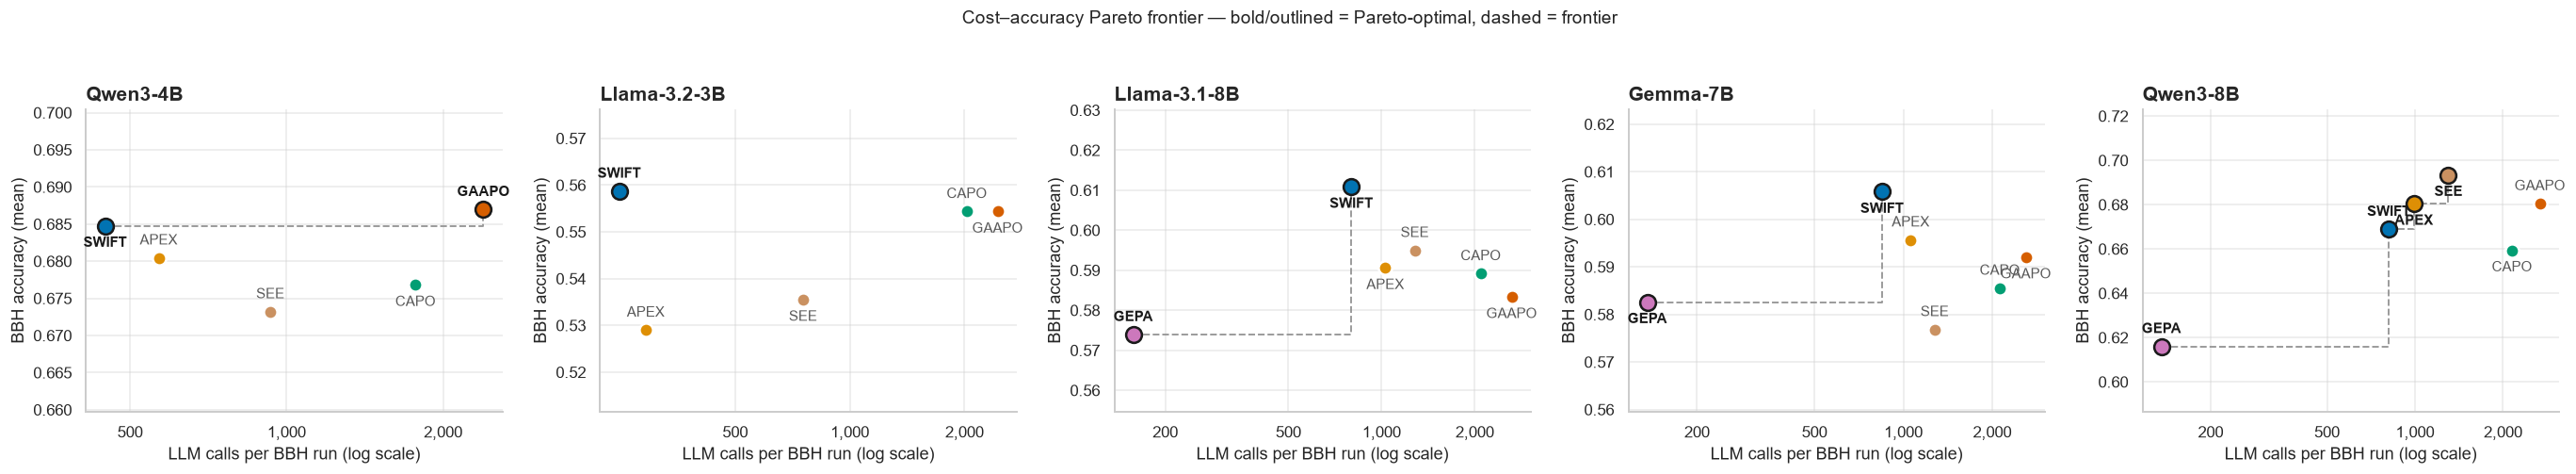

In [11]:
eff = (runs[runs.benchmark == "bbh"]
       .groupby(["model", "Method"])
       .agg(acc=("test_score", "mean"), calls=("calls", "mean"),
            tokens=("tokens", "mean"), time=("total_time", "mean"),
            tokens_out=("tokens_out", "mean"), tokens_in=("tokens_in", "mean"))
       .reset_index())
eff["tok_per_s"] = eff.tokens / eff.time

def pareto(df, xcol, ycol):
    keep = []
    for i, r in df.iterrows():
        if not ((df[xcol] < r[xcol]) & (df[ycol] > r[ycol])).any():
            keep.append(i)
    return keep

fmodels = [m for m in MODEL_ORDER if m in eff.model.unique()]
fig, axes = plt.subplots(1, len(fmodels), figsize=(4.8 * len(fmodels), 4.2), squeeze=False)
for ax, model in zip(axes[0], fmodels):
    sub = eff[eff.model == model].reset_index(drop=True)
    front = pareto(sub, "calls", "acc")
    fs = sub.loc[front].sort_values("calls")
    ax.step(fs.calls, fs.acc, where="post", c="0.6", lw=1.2, zorder=1, ls="--")
    # alternate label offsets so annotations never collide
    sub = sub.sort_values("acc").reset_index()  # 'index' keeps original row id
    for i, r in sub.iterrows():
        on_front = r["index"] in front
        ax.scatter(r.calls, r.acc, color=LPALETTE[r.Method], s=110 if on_front else 80,
                   edgecolor="k" if on_front else "white", linewidth=1.6, zorder=3)
        dy = 9 if i % 2 == 0 else -14
        ax.annotate(r.Method, (r.calls, r.acc), fontsize=9.5,
                    fontweight="bold" if on_front else "normal",
                    color="0.1" if on_front else "0.35",
                    xytext=(0, dy), textcoords="offset points", ha="center")
    ax.set_xscale("log"); ax.set_title(model, loc="left")
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())  # avoid crowded minor labels
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    pad = (sub.acc.max() - sub.acc.min()) * 0.25 + 0.01
    ax.set_ylim(sub.acc.min() - pad, sub.acc.max() + pad)
    ax.set_xlabel("LLM calls per BBH run (log scale)")
    ax.set_ylabel("BBH accuracy (mean)")
fig.suptitle("Cost–accuracy Pareto frontier — bold/outlined = Pareto-optimal, "
             "dashed = frontier", y=1.04, fontsize=12)
tl(); plt.show()

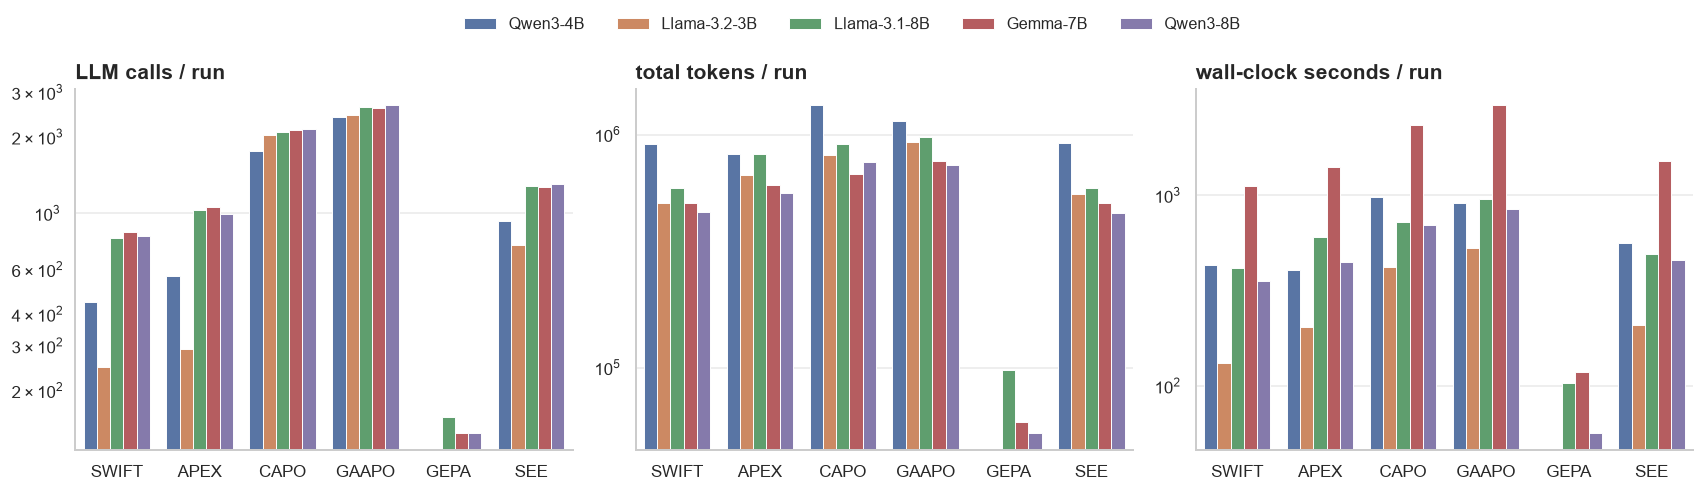

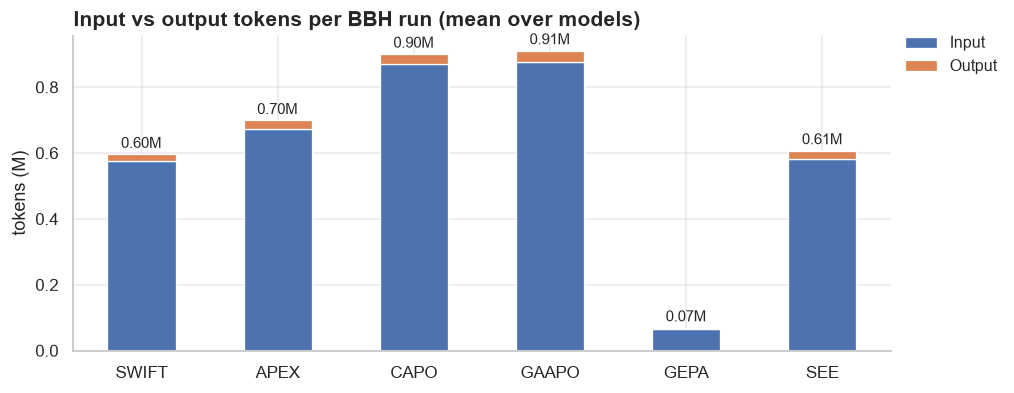

Method
APEX     1674.0
CAPO     1185.0
GAAPO    1035.0
GEPA      784.0
SEE      1367.0
SWIFT    1822.0


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in eff.Method.unique()]
for ax, (col, lab) in zip(axes, [("calls", "LLM calls / run"),
                                 ("tokens", "total tokens / run"),
                                 ("time", "wall-clock seconds / run")]):
    sns.barplot(data=eff, x="Method", y=col, order=order, hue="model",
                hue_order=fmodels, ax=ax, errorbar=None,
                edgecolor="white", linewidth=0.6)
    ax.set_yscale("log"); ax.set_title(lab, loc="left")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
shared_top_legend(fig, list(axes), ncol=len(fmodels), y=0.99)
tl(); plt.show()

io = (eff.groupby("Method")[["tokens_in", "tokens_out"]].mean().loc[order] / 1e6)
io.columns = ["Input", "Output"]
fig, ax = plt.subplots(figsize=(9, 3.6))
io.plot(kind="bar", stacked=True, ax=ax, color=["#4c72b0", "#dd8452"],
        edgecolor="white", linewidth=0.8, rot=0)
for i, (idx, row) in enumerate(io.iterrows()):
    ax.annotate(f"{row.sum():.2f}M", (i, row.sum()), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9.5)
ax.set_ylabel("tokens (M)"); ax.set_xlabel("")
ax.set_title("Input vs output tokens per BBH run (mean over models)", loc="left")
legend_right(ax)
tl(); plt.show()
print(eff.groupby("Method")["tok_per_s"].mean().round(0).rename("tokens/sec (mean)").to_string())

---
# Part III · Mechanisms — how each method searches

*(RQ3)* Parts I–II said *what* happened; this part explains *why*. Using the per-generation history and the full candidate genealogy, we reconstruct how each optimizer spends its budget over time (§7), whether its selection process overfits (§8), which of its operators actually produce improvements (§9), and what happens to the prompts themselves as the search runs (§10).

## 7 · Search dynamics: time and samples

**Question: how quickly does each method reach its final quality — and how much search does that take?** Two complementary views:

- **Anytime (wall-clock)** — per-generation timestamps reconstruct the true trajectory of the best dev score: what score would you have if you stopped the optimizer after *t* seconds? The **normalized anytime AUC** compresses each curve to one number (1.0 = at final quality instantly). This rewards methods that surface good prompts early — invisible in end-point tables.
- **Sample efficiency (GEPA-style)** — the same trajectory against *cumulative candidates generated* instead of seconds: quality per unit of search, GEPA's headline metric, computed here for every method from the genealogy.

**How to read them:** curves hugging the top-left corner win. A method can look fast on wall-clock but expensive per candidate (parallel-heavy search), or vice versa — comparing the two panels separates those profiles.

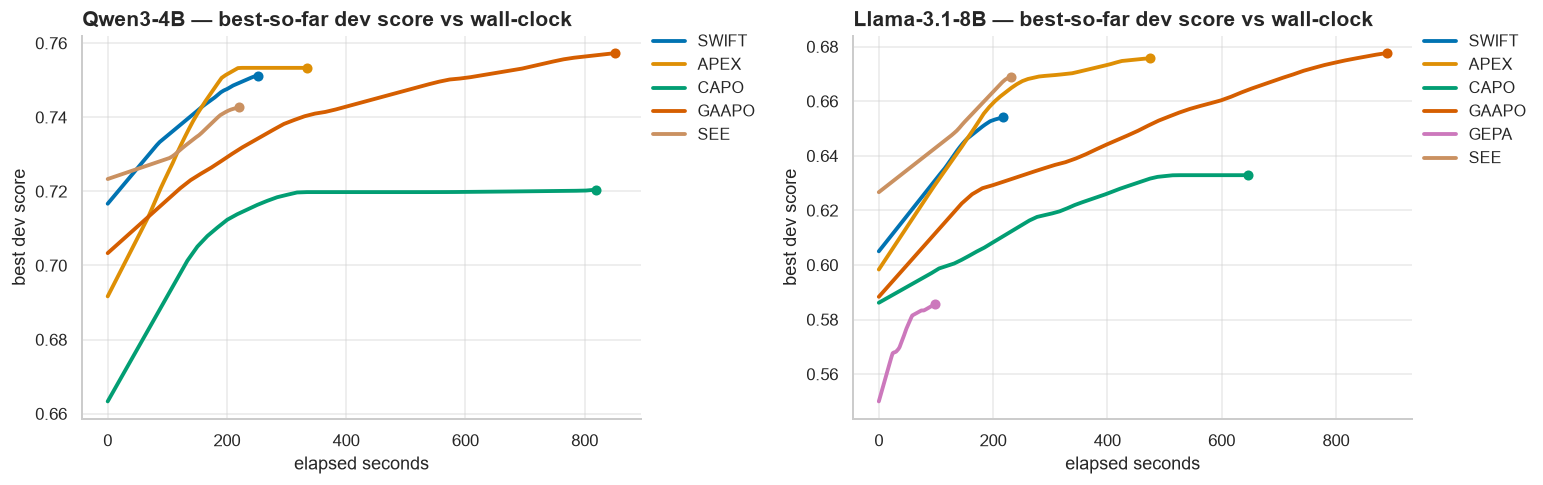

Normalized anytime AUC (1.0 = final quality reached immediately):
         mean    std
Method              
APEX    0.965  0.039
CAPO    0.972  0.031
GAAPO   0.956  0.044
GEPA    0.985  0.027
SEE     0.964  0.046
SWIFT   0.974  0.029


In [13]:
def anytime_curves(traj_df):
    rows = []
    for (model, method, task, seed), g in traj_df.groupby(["model", "method", "task", "seed"]):
        g = g.sort_values("generation")
        ts = pd.to_datetime(g.timestamp, errors="coerce")
        if ts.isna().any() or len(g) < 2:
            continue
        el = (ts - ts.iloc[0]).dt.total_seconds().values
        best = np.maximum.accumulate(g.best_score.values)
        for e, b, gen in zip(el, best, g.generation):
            rows.append(dict(model=model, method=method, task=task, seed=seed,
                             elapsed=e, best=b, generation=gen))
    return pd.DataFrame(rows)

any_df = anytime_curves(traj[traj.benchmark == "bbh"])
any_df["Method"] = any_df.method.map(METHOD_LABEL)

show_models = [m for m in ["Qwen3-4B", "Llama-3.1-8B"] if m in any_df.model.unique()]
fig, axes = plt.subplots(1, len(show_models), figsize=(6.8 * len(show_models), 4.4),
                         squeeze=False)
for ax, model in zip(axes[0], show_models):
    sub = any_df[any_df.model == model]
    for m in METHODS:
        s = sub[sub.method == m]
        if s.empty:
            continue
        # mean best-so-far on a common elapsed grid
        grid = np.linspace(0, s.groupby(["task", "seed"]).elapsed.max().median(), 50)
        curves = []
        for _, gg in s.groupby(["task", "seed"]):
            gg = gg.sort_values("elapsed")
            curves.append(np.interp(grid, gg.elapsed, gg.best))
        mc = np.mean(curves, axis=0)
        ax.plot(grid, mc, label=METHOD_LABEL[m], color=PALETTE[m], lw=2.4)
        ax.scatter(grid[-1], mc[-1], color=PALETTE[m], s=28, zorder=3)
    ax.set_title(f"{model} — best-so-far dev score vs wall-clock", loc="left")
    ax.set_xlabel("elapsed seconds"); ax.set_ylabel("best dev score")
    legend_right(ax)
tl(); plt.show()

# normalized anytime AUC per run
aucs = []
for (model, method, task, seed), gg in any_df.groupby(["model", "method", "task", "seed"]):
    gg = gg.sort_values("elapsed")
    if gg.elapsed.iloc[-1] <= 0:
        continue
    x = gg.elapsed / gg.elapsed.iloc[-1]
    y = gg.best / gg.best.iloc[-1] if gg.best.iloc[-1] > 0 else gg.best
    trap = getattr(np, "trapezoid", None) or np.trapz
    aucs.append(dict(model=model, Method=METHOD_LABEL[method],
                     auc=trap(y, x)))
aucs = pd.DataFrame(aucs)
print("Normalized anytime AUC (1.0 = final quality reached immediately):")
print(aucs.groupby("Method").auc.agg(["mean", "std"]).round(3).to_string())

**Sample efficiency (GEPA-style).** GEPA's headline claim is quality *per rollout*, not per second. Here the x-axis is the cumulative number of **candidates generated** (from the audit genealogy) and y is the best dev score reached by that point — how much search does each method need before it finds its good prompts?

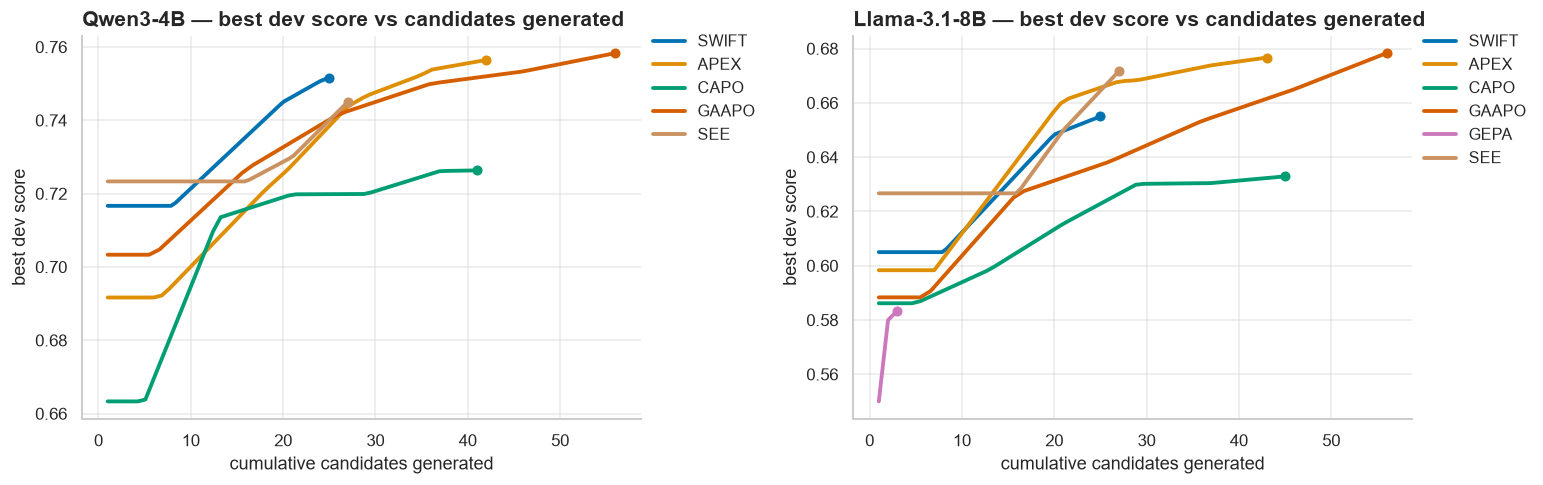

In [14]:
cand_per_gen = (cand[cand.benchmark == "bbh"]
                .groupby(["model", "method", "task", "seed", "generation"])
                .size().rename("n").reset_index())
rows = []
for (model, method, task, seed), g in traj[traj.benchmark == "bbh"].groupby(
        ["model", "method", "task", "seed"]):
    g = g.sort_values("generation")
    cg = cand_per_gen[(cand_per_gen.model == model) & (cand_per_gen.method == method) &
                      (cand_per_gen.task == task) & (cand_per_gen.seed == seed)]
    counts = cg.set_index("generation").n
    if counts.empty:
        continue
    cum = 0
    best = -np.inf
    for _, r in g.iterrows():
        cum += int(counts.get(r.generation, 0))
        best = max(best, r.best_score)
        rows.append(dict(model=model, method=method, task=task, seed=seed,
                         cands=cum, best=best))
se = pd.DataFrame(rows)

show_models = [m for m in ["Qwen3-4B", "Llama-3.1-8B"] if m in se.model.unique()]
fig, axes = plt.subplots(1, len(show_models), figsize=(6.8 * len(show_models), 4.4),
                         squeeze=False)
for ax, model in zip(axes[0], show_models):
    sub = se[se.model == model]
    for m in METHODS:
        s = sub[sub.method == m]
        if s.empty:
            continue
        grid = np.linspace(1, s.groupby(["task", "seed"]).cands.max().median(), 50)
        curves = []
        for _, gg in s.groupby(["task", "seed"]):
            gg = gg.sort_values("cands")
            curves.append(np.interp(grid, gg.cands, gg.best))
        mc = np.mean(curves, axis=0)
        ax.plot(grid, mc, label=METHOD_LABEL[m], color=PALETTE[m], lw=2.4)
        ax.scatter(grid[-1], mc[-1], color=PALETTE[m], s=28, zorder=3)
    ax.set_title(f"{model} — best dev score vs candidates generated", loc="left")
    ax.set_xlabel("cumulative candidates generated"); ax.set_ylabel("best dev score")
    legend_right(ax)
tl(); plt.show()

## 8 · Selection integrity: does dev-set selection overfit?

**Question: when a method picks its "best" prompt on the dev split, does that choice hold up on the held-out test set?** The **generalization gap** `best_dev − test` measures selection overfitting. Methods that screen candidates on *fresh, resampled* minibatches (SWIFT/APEX by design; GEPA with its binary improvement test) should show smaller positive gaps than methods that select against a fixed dev subset — this section is the empirical check of that design argument.

**How to read it:** points below the diagonal chose prompts that looked better on dev than they are; the boxplot ranks methods by how much of their reported dev quality survives contact with the test set.

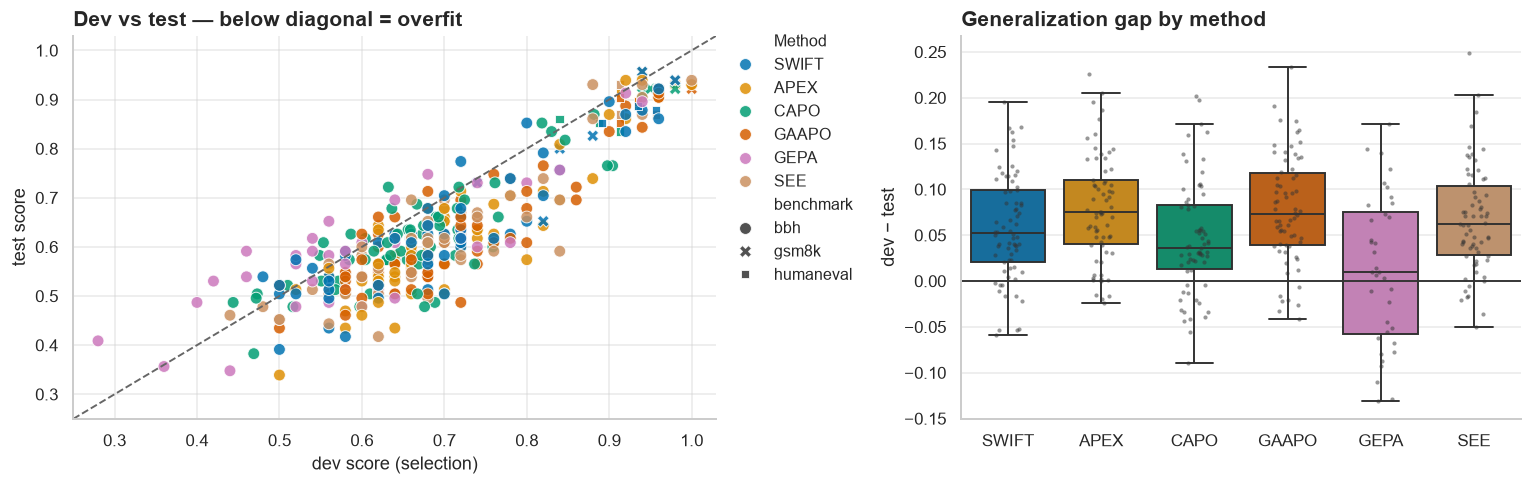

         mean    std  count
Method                     
APEX    0.079  0.058     66
CAPO    0.046  0.062     66
GAAPO   0.078  0.059     66
GEPA    0.012  0.082     36
SEE     0.067  0.058     66
SWIFT   0.058  0.058     70


In [15]:
g = runs.dropna(subset=["best_dev", "test_score"]).copy()
g["gap"] = g.best_dev - g.test_score
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), width_ratios=[1.15, 1])
order = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in g.Method.unique()]
sns.scatterplot(data=g, x="best_dev", y="test_score", hue="Method", hue_order=order,
                style="benchmark", palette=LPALETTE, ax=axes[0], s=55, alpha=0.85)
lims = [g[["best_dev", "test_score"]].min().min() - .03,
        g[["best_dev", "test_score"]].max().max() + .03]
axes[0].plot(lims, lims, "--", c="0.4", lw=1.2)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("dev score (selection)"); axes[0].set_ylabel("test score")
axes[0].set_title("Dev vs test — below diagonal = overfit", loc="left")
legend_right(axes[0])
sns.boxplot(data=g, x="Method", y="gap", order=order, palette=LPALETTE,
            ax=axes[1], showfliers=False, linewidth=1.2)
sns.stripplot(data=g, x="Method", y="gap", order=order, ax=axes[1],
              color="0.2", size=2.6, alpha=0.5, jitter=0.15)
axes[1].axhline(0, c="0.2", lw=1.2)
axes[1].set_xlabel(""); axes[1].set_ylabel("dev − test")
axes[1].set_title("Generalization gap by method", loc="left")
axes[1].tick_params(axis="x", rotation=0)
tl(); plt.show()
print(g.groupby("Method")["gap"].agg(["mean", "std", "count"]).round(3).to_string())

## 9 · Operator economics: which operators do the work?

**Question: inside each method, which candidate-generation operators actually produce improvements — and which just burn budget?** The genealogy records, for every one of the ~10,000 generated candidates, the operator that produced it and its parent's dev score. Three ledgers follow:

- **Usage** — how each method allocates its generation budget across operators.
- **Gate pass rate** — the share of candidates that survived screening to receive a full dev evaluation.
- **Improvement over parent** — `dev(child) − dev(parent)` per operator: the operator's actual production, not its popularity.

**How to read it:** most operators have negative *mean* improvement — that is expected (most mutations are worse than a strong parent; search only needs occasional wins). The informative column is **P(child improves on parent)**: operators above ~0.3 are reliable workhorses; operators near 0.05 are lottery tickets. Cross-reference with the usage heatmap to spot methods spending heavily on lottery tickets.

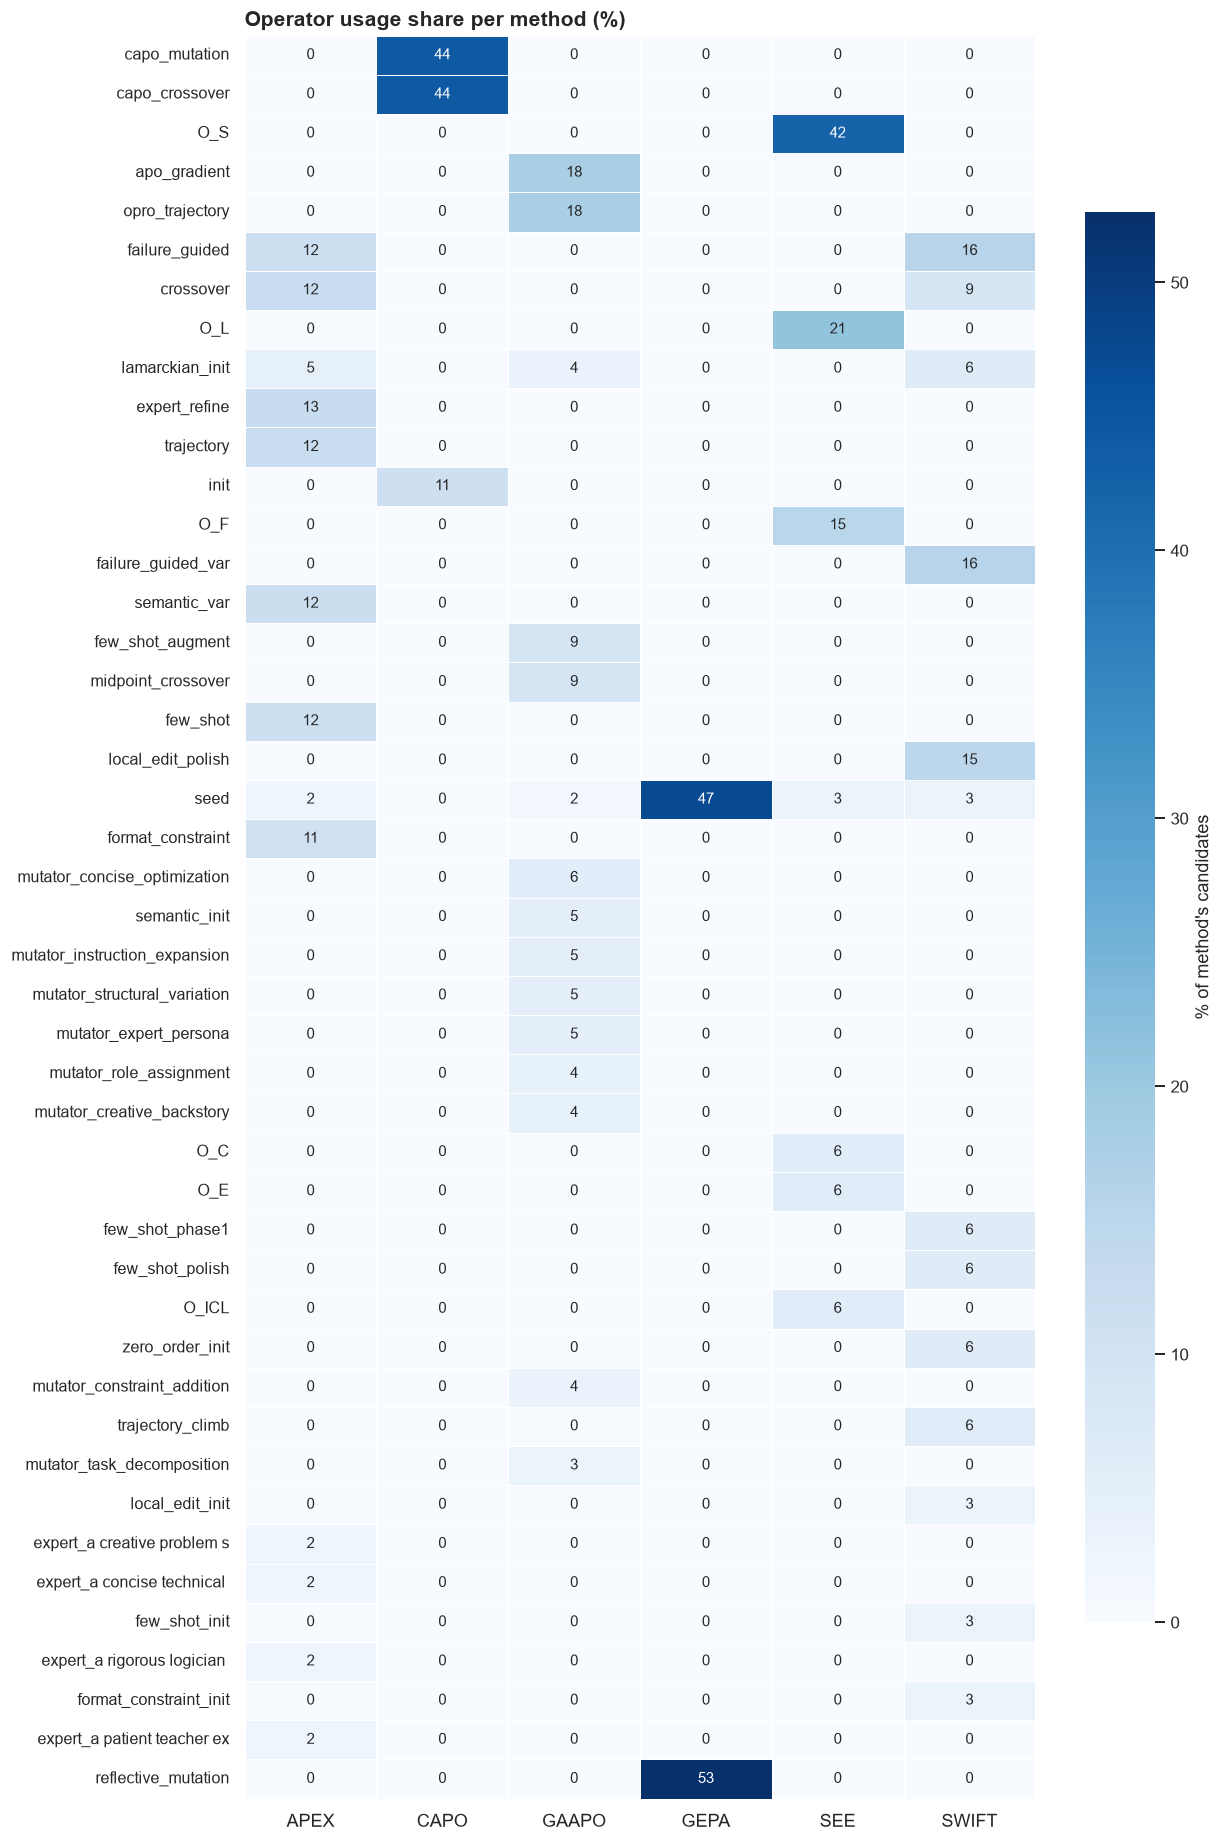

In [16]:
cb = cand[cand.benchmark == "bbh"].copy()
usage = (cb.groupby(["Method", "operator"]).size().rename("n").reset_index())
top_ops = usage.groupby("operator").n.sum().sort_values(ascending=False).index
pv = (usage.pivot(index="operator", columns="Method", values="n")
      .reindex(top_ops).fillna(0))
pv_pct = pv / pv.sum() * 100
fig, ax = plt.subplots(figsize=(11, max(4.5, 0.36 * len(pv))))
sns.heatmap(pv_pct, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5,
            annot_kws={"fontsize": 9.5},
            cbar_kws={"label": "% of method's candidates", "shrink": 0.8}, ax=ax)
ax.set_title("Operator usage share per method (%)", loc="left")
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=10)
tl(); plt.show()

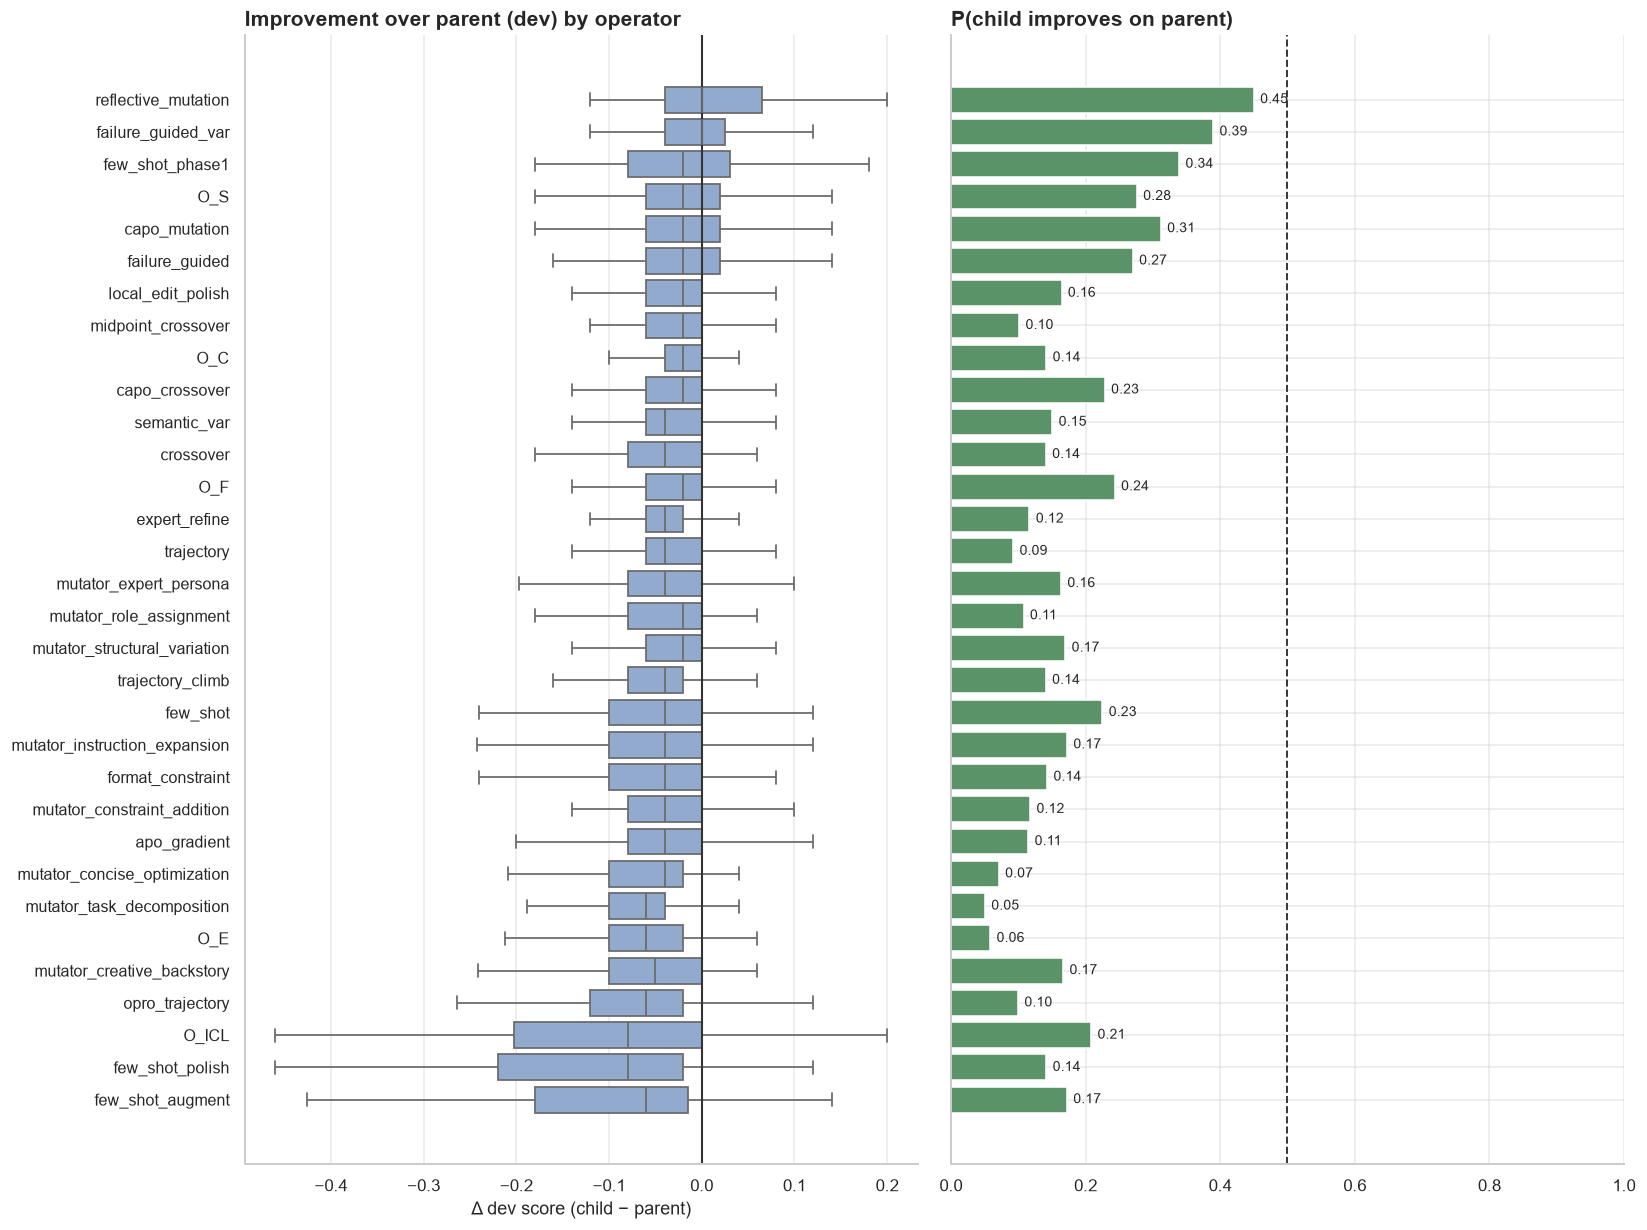

                                  n  mean_delta  p_improve
operator                                                  
reflective_mutation              40       0.007      0.450
failure_guided_var              172      -0.003      0.390
few_shot_phase1                  59      -0.019      0.339
O_S                             840      -0.022      0.276
capo_mutation                  1164      -0.024      0.312
failure_guided                  322      -0.024      0.270
local_edit_polish               274      -0.030      0.164
midpoint_crossover              296      -0.030      0.101
O_C                             120      -0.030      0.142
capo_crossover                 1164      -0.036      0.229
semantic_var                    166      -0.039      0.151
crossover                       305      -0.041      0.141
O_F                             300      -0.041      0.243
expert_refine                   180      -0.041      0.117
trajectory                      173      -0.043      0.0

In [17]:
imp = cb.dropna(subset=["dev", "parent_dev"]).copy()
imp["delta"] = imp.dev - imp.parent_dev
if not imp.empty:
    op_stats = (imp.groupby("operator")
                .agg(n=("delta", "size"), mean_delta=("delta", "mean"),
                     p_improve=("delta", lambda s: (s > 0).mean()))
                .query("n >= 10").sort_values("mean_delta", ascending=False))
    keep = op_stats.index
    fig, axes = plt.subplots(1, 2, figsize=(14.5, max(5, 0.34 * len(keep))),
                             sharey=True)
    sns.boxplot(data=imp[imp.operator.isin(keep)], y="operator", x="delta",
                order=keep, ax=axes[0], color="#88a8d8",
                showfliers=False, linewidth=1.1)
    axes[0].axvline(0, c="0.2", lw=1.3)
    axes[0].set_title("Improvement over parent (dev) by operator", loc="left")
    axes[0].set_xlabel("Δ dev score (child − parent)"); axes[0].set_ylabel("")
    axes[0].tick_params(axis="y", labelsize=10)
    bars = axes[1].barh(range(len(keep)), op_stats.p_improve.loc[keep],
                        color="#5a9367", edgecolor="white")
    axes[1].set_yticks(range(len(keep)))
    axes[1].axvline(0.5, c="0.2", ls="--", lw=1.2)
    axes[1].set_title("P(child improves on parent)", loc="left")
    axes[1].set_xlim(0, 1)
    for y_, v_ in enumerate(op_stats.p_improve.loc[keep]):
        axes[1].annotate(f"{v_:.2f}", (v_, y_), xytext=(4, 0),
                         textcoords="offset points", va="center", fontsize=8.5)
    tl(); plt.show()
    print(op_stats.round(3).to_string())

gate = (cb[cb.n_parents > 0].groupby("Method")["is_complete"]
        .agg(pass_rate="mean", n="size"))
print("\nGate pass rate (share of non-seed candidates receiving full dev eval):")
print(gate.round(3).to_string())

## 10 · The prompts themselves: evolution, diversity, and quality

**Question: what kind of text does each optimizer actually produce, and how does it get there?** The final lens of Part III turns from scores to the prompts, in four steps computed from candidate texts in the genealogy:

- **Length dynamics** (§10.1) — words per generation. Length inflation is a known APO failure mode; CAPO explicitly penalizes it.
- **Edit distance & drift** (§10.2) — `1 − SequenceMatcher.ratio` between child and parent, per generation (the literature reports large early edits that shrink as search converges), plus how far each *winning* prompt drifted from the seed it started from.
- **Population diversity** (§10.3) — do populations stay diverse (exploration) or collapse to near-duplicates?
- **Readability & lexical profile** (§10.4) — Flesch Reading Ease, length, and type–token ratio of winning prompts vs. their seeds.

### 10.1 Length dynamics

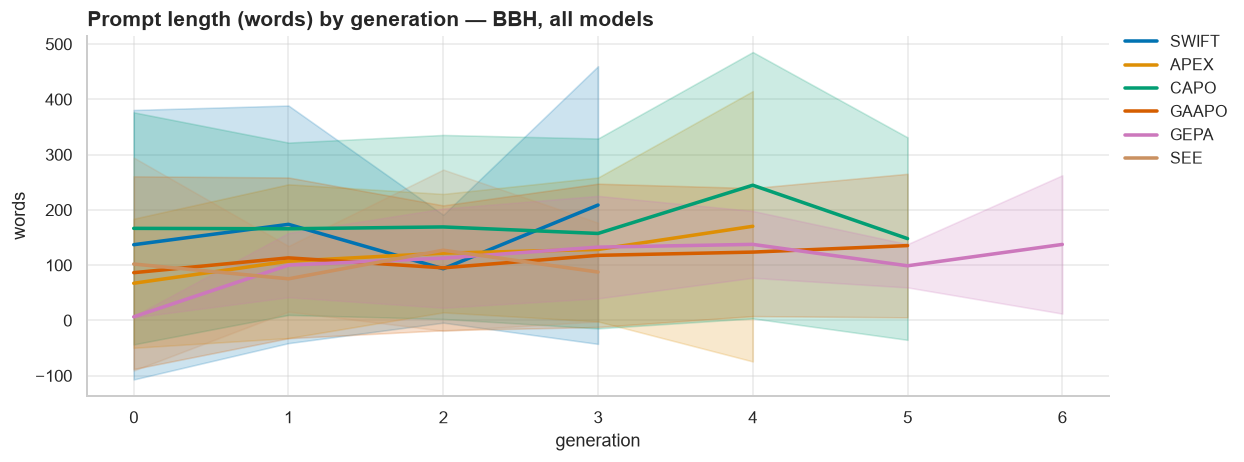

In [18]:
cb_txt = cb[(cb.text.str.len() > 0)].copy()
cb_txt["words"] = cb_txt.text.str.split().str.len()
fig, ax = plt.subplots(figsize=(11, 4.2))
sns.lineplot(data=cb_txt, x="generation", y="words", hue="Method",
             hue_order=[METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in cb_txt.Method.unique()],
             palette=LPALETTE, estimator="mean", errorbar="sd", ax=ax, lw=2.2)
ax.set_title("Prompt length (words) by generation — BBH, all models", loc="left")
ax.set_xlabel("generation"); ax.set_ylabel("words")
ax.xaxis.get_major_locator().set_params(integer=True)
legend_right(ax)
tl(); plt.show()

### 10.2 Edit distance and drift from the seed

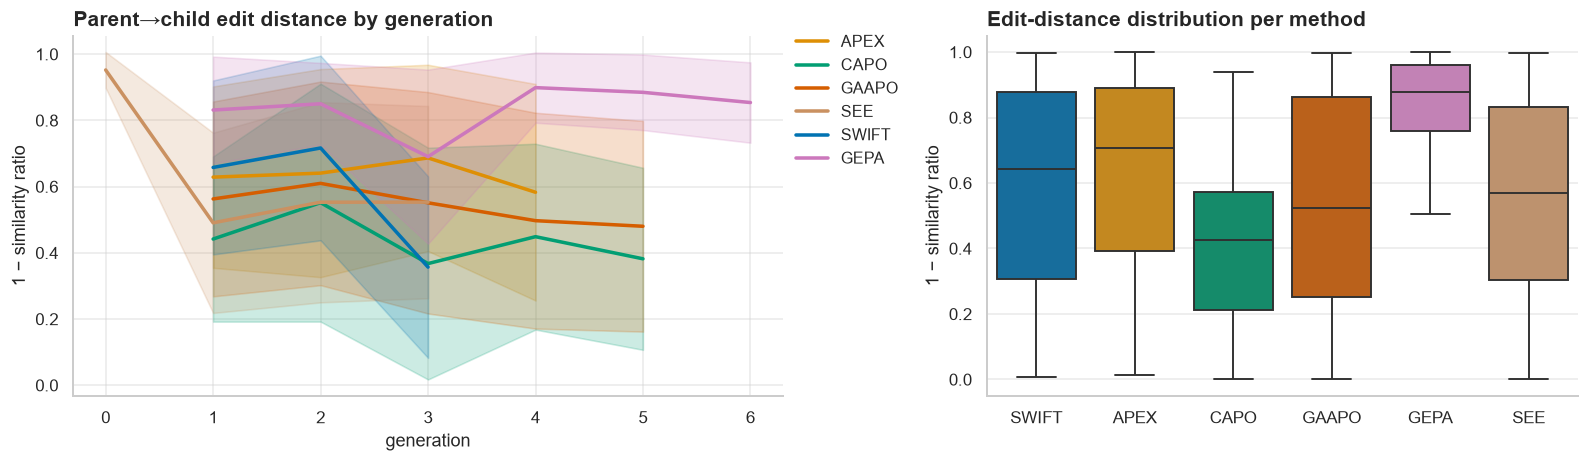

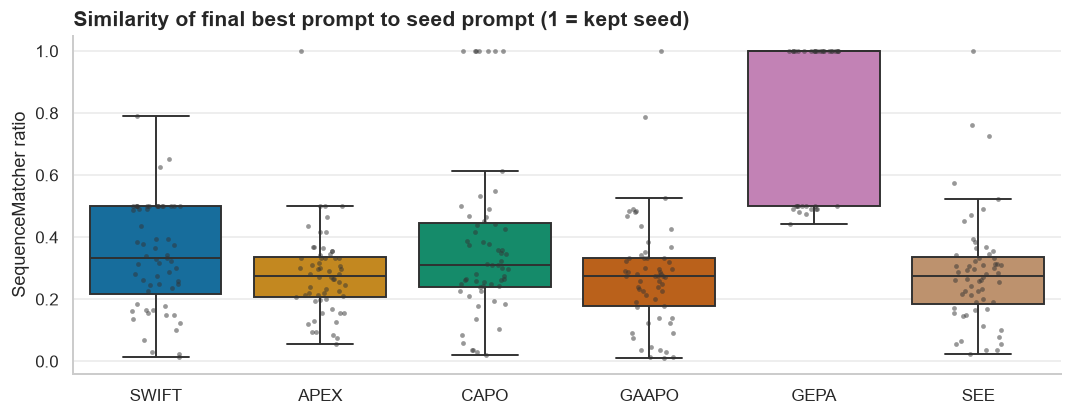

Method
GAAPO    0.276
APEX     0.283
SEE      0.287
SWIFT    0.338
CAPO     0.378
GEPA     0.802


In [19]:
ed = cb_txt[(cb_txt.parent_text.str.len() > 0)].copy()
if not ed.empty:
    ed["edit_dist"] = [1 - SequenceMatcher(None, a, b).ratio()
                       for a, b in zip(ed.parent_text, ed.text)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), width_ratios=[1.2, 1])
    sns.lineplot(data=ed, x="generation", y="edit_dist", hue="Method",
                 palette=LPALETTE, estimator="mean", errorbar="sd",
                 ax=axes[0], lw=2.2)
    axes[0].set_title("Parent→child edit distance by generation", loc="left")
    axes[0].set_ylabel("1 − similarity ratio"); axes[0].set_xlabel("generation")
    axes[0].xaxis.get_major_locator().set_params(integer=True)
    legend_right(axes[0])
    sns.boxplot(data=ed, x="Method", y="edit_dist",
                order=[METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in ed.Method.unique()],
                palette=LPALETTE, ax=axes[1], showfliers=False, linewidth=1.2)
    axes[1].set_title("Edit-distance distribution per method", loc="left")
    axes[1].set_xlabel(""); axes[1].set_ylabel("1 − similarity ratio")
    axes[1].tick_params(axis="x", rotation=0)
    tl(); plt.show()

# drift of the winning prompt from the seed prompt
rows = []
for (model, method, task, seed), bp in best_prompts.items():
    sp = seed_prompts.get((model, task), "")
    if bp and sp and benchmark_of(task) == "bbh":
        sim = SequenceMatcher(None, sp, bp[:len(sp) * 3]).ratio()
        rows.append(dict(model=model, Method=METHOD_LABEL.get(method, method),
                         sim_to_seed=sim))
drift = pd.DataFrame(rows)
if not drift.empty:
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    dorder = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in drift.Method.unique()]
    sns.boxplot(data=drift, x="Method", y="sim_to_seed", order=dorder,
                palette=LPALETTE, ax=ax, showfliers=False, linewidth=1.2)
    sns.stripplot(data=drift, x="Method", y="sim_to_seed", order=dorder,
                  ax=ax, color="0.2", size=3, alpha=0.5, jitter=0.15)
    ax.set_title("Similarity of final best prompt to seed prompt (1 = kept seed)",
                 loc="left")
    ax.set_ylabel("SequenceMatcher ratio"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    tl(); plt.show()
    print(drift.groupby("Method").sim_to_seed.mean().round(3).sort_values().to_string())

### 10.3 Population diversity (PromptBreeder/EvoPrompt-style)

Evolutionary methods argue diversity prevents premature convergence. We measure the mean pairwise text distance among each generation's candidates (per run, up to 8 sampled candidates per generation for tractability). Sustained high diversity = broad exploration; collapse toward 0 = the population has converged to near-duplicates.

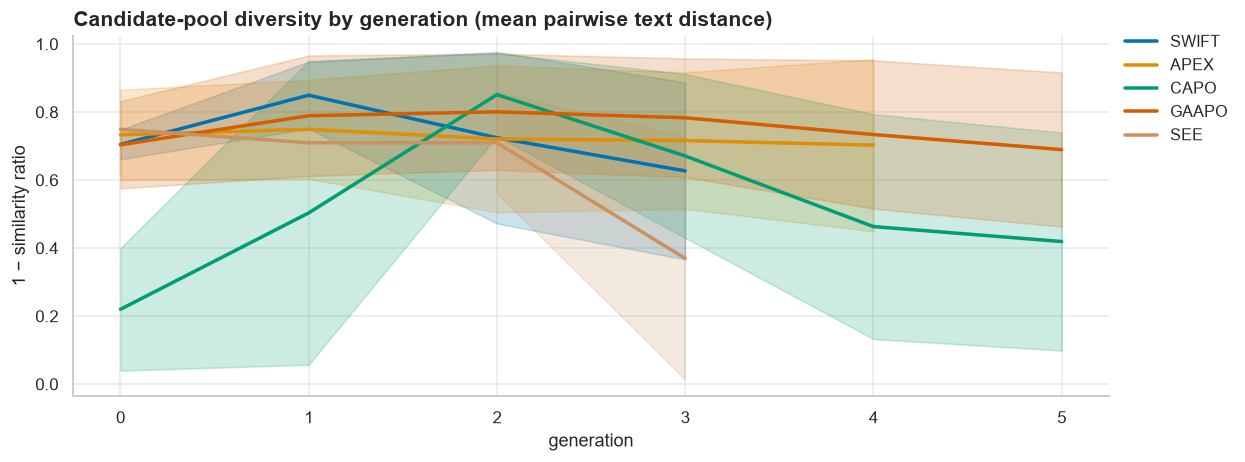

Method
GAAPO    0.747
APEX     0.731
SWIFT    0.726
SEE      0.707
CAPO     0.506


In [20]:
def gen_diversity(texts, cap=8, tlen=400):
    texts = [t[:tlen] for t in texts if t][:cap]
    if len(texts) < 2:
        return np.nan
    ds = [1 - SequenceMatcher(None, a, b).ratio()
          for i, a in enumerate(texts) for b in texts[i + 1:]]
    return float(np.mean(ds))

div_rows = []
for (model, method, task, seed, gen), g in cb_txt.groupby(
        ["model", "method", "task", "seed", "generation"]):
    d_ = gen_diversity(g.text.tolist())
    if not np.isnan(d_):
        div_rows.append(dict(model=model, Method=METHOD_LABEL[method],
                             generation=gen, diversity=d_))
dv = pd.DataFrame(div_rows)
if not dv.empty:
    fig, ax = plt.subplots(figsize=(11, 4.2))
    sns.lineplot(data=dv, x="generation", y="diversity", hue="Method",
                 hue_order=[METHOD_LABEL[m] for m in METHODS
                            if METHOD_LABEL[m] in dv.Method.unique()],
                 palette=LPALETTE, estimator="mean", errorbar="sd", ax=ax, lw=2.2)
    ax.set_title("Candidate-pool diversity by generation (mean pairwise text distance)",
                 loc="left")
    ax.set_xlabel("generation"); ax.set_ylabel("1 − similarity ratio")
    ax.xaxis.get_major_locator().set_params(integer=True)
    legend_right(ax)
    tl(); plt.show()
    print(dv.groupby("Method").diversity.mean().round(3)
          .sort_values(ascending=False).rename("mean diversity").to_string())

### 10.4 Readability & lexical profile of winning prompts

**Flesch Reading Ease** (higher = simpler English; computed with a standard syllable heuristic) plus lexical statistics of each run's *winning* prompt vs its seed. Reported findings in the prompt-engineering literature associate effective prompts with brevity, action-driven phrasing, and tight vocabulary — this cell tests whether winning prompts actually move that way.

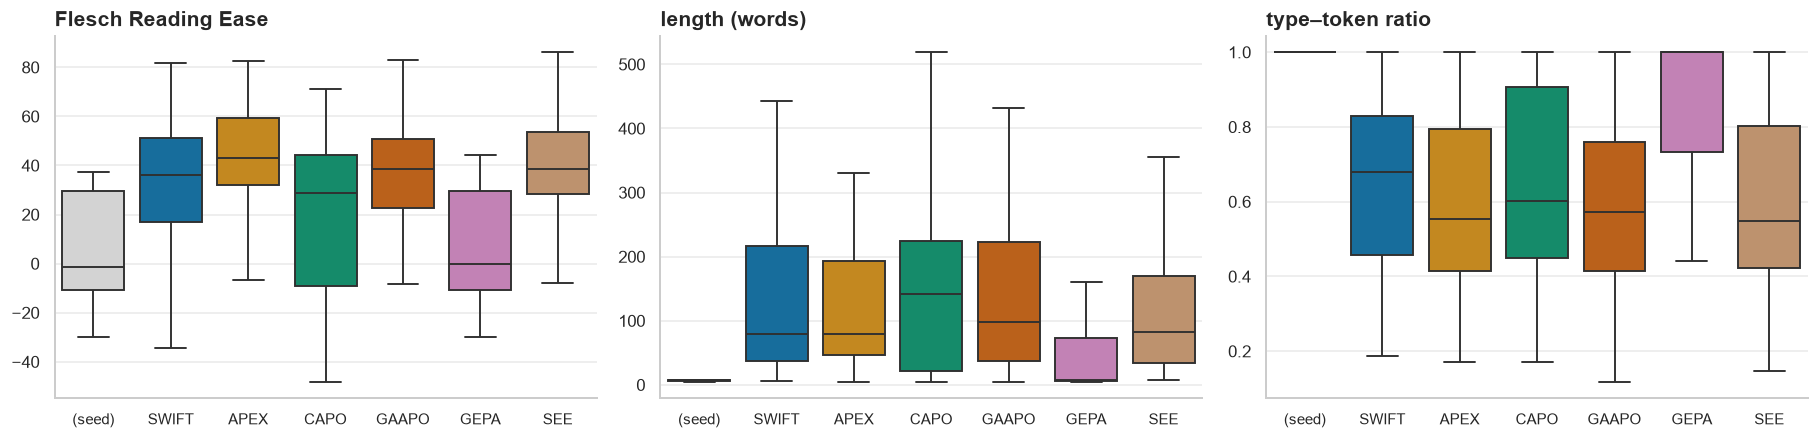

        flesch   words   ttr
Method                      
APEX     42.24  157.82  0.59
CAPO     20.36  175.07  0.66
GAAPO    35.19  151.33  0.59
GEPA      7.41   49.19  0.86
SEE      39.51  144.35  0.59
SWIFT    33.38  197.17  0.63


In [21]:
VOWELS = re.compile(r"[aeiouy]+", re.I)
def syllables(word):
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    n = len(VOWELS.findall(w))
    return max(1, n - (1 if w.endswith("e") and n > 1 else 0))

def flesch(text):
    sents = max(1, len(re.findall(r"[.!?]+", text)) or 1)
    words = [w for w in re.findall(r"[A-Za-z']+", text)]
    if not words:
        return np.nan
    syl = sum(syllables(w) for w in words)
    return 206.835 - 1.015 * len(words) / sents - 84.6 * syl / len(words)

def ttr(text):
    words = [w.lower() for w in re.findall(r"[A-Za-z']+", text)]
    return len(set(words)) / len(words) if words else np.nan

rows = []
for (model, method, task, seed), bp in best_prompts.items():
    if not bp or benchmark_of(task) != "bbh":
        continue
    rows.append(dict(model=model, Method=METHOD_LABEL.get(method, method), kind="best",
                     flesch=flesch(bp), words=len(bp.split()), ttr=ttr(bp)))
for (model, task), sp in seed_prompts.items():
    if benchmark_of(task) == "bbh" and sp:
        rows.append(dict(model=model, Method="(seed)", kind="seed",
                         flesch=flesch(sp), words=len(sp.split()), ttr=ttr(sp)))
qual = pd.DataFrame(rows)
order_q = ["(seed)"] + [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in qual.Method.unique()]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, lab) in zip(axes, [("flesch", "Flesch Reading Ease"),
                                 ("words", "length (words)"),
                                 ("ttr", "type–token ratio")]):
    sns.boxplot(data=qual, x="Method", y=col, order=order_q, ax=ax,
                palette={**LPALETTE, "(seed)": "lightgray"},
                showfliers=False, linewidth=1.2)
    ax.set_title(lab, loc="left"); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0, labelsize=9.5)
tl(); plt.show()
print(qual[qual.kind == "best"].groupby("Method")[["flesch", "words", "ttr"]]
      .mean().round(2).to_string())

---
# Part IV · The evidence up close

Aggregates can hide as much as they show. This part descends to individual test items and individual prompts: which problems the methods agree on (§11), and what the successes, failures, and winning prompts actually look like (§12).

## 11 · Do methods solve the same problems?

**Question: when two methods score 0.94 and 0.92, are they solving the same 92% — or different subsets?** Result files store per-test-item predictions on GSM8K and HumanEval, enabling the **hardness spectrum** (items solved by all / some / no methods) and **pairwise agreement** (Jaccard similarity of solved sets).

**How to read it:** mass concentrated at "all methods solve it" + high Jaccard = methods converge on equivalent prompts, and ensembling would add nothing; a fat middle of the spectrum + low Jaccard = complementary strengths worth exploiting. The printout compares the best single method against the oracle union of all methods.

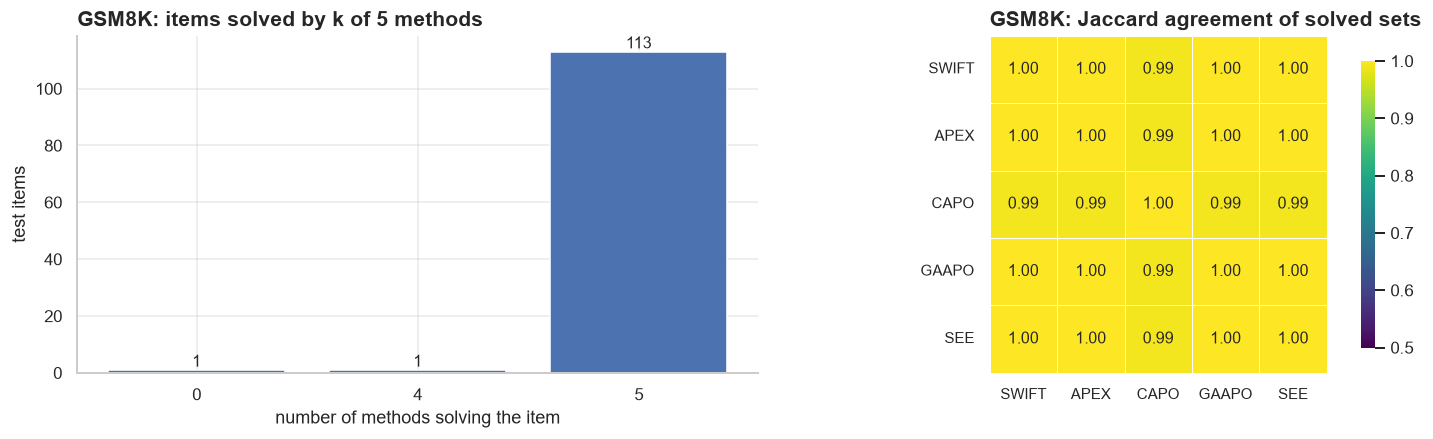

GSM8K: best single method 0.991 | oracle union of all methods 0.991 | unsolved by everyone: 1 items


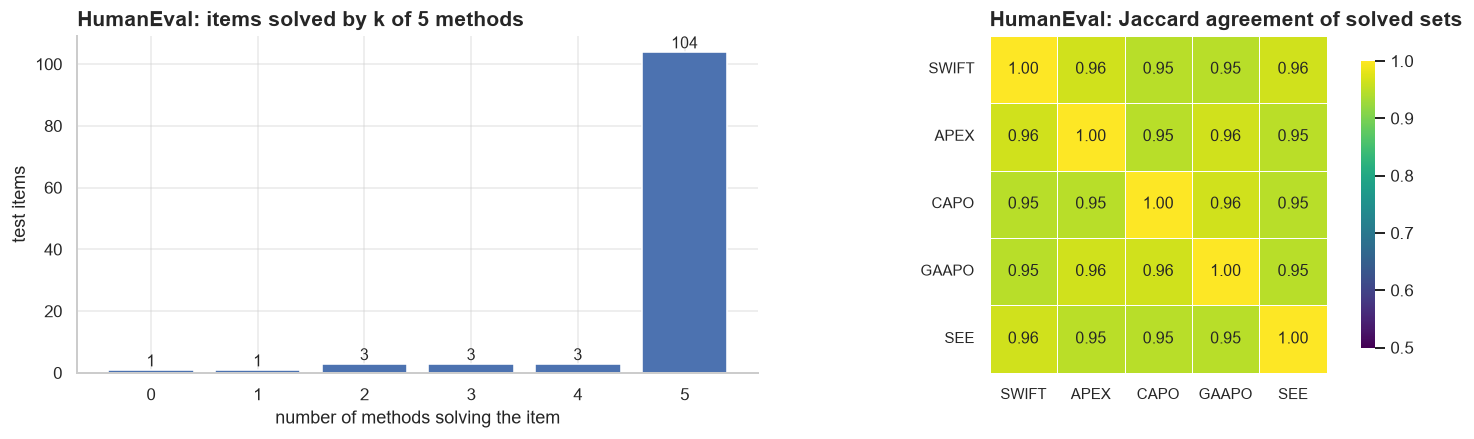

HumanEval: best single method 0.974 | oracle union of all methods 0.991 | unsolved by everyone: 1 items


In [22]:
for bench in ["gsm8k", "humaneval"]:
    mats = {}
    for m in METHODS:
        per_seed = []
        for seed in sorted({k[3] for k in per_sample if k[1] == m and k[2] == bench and k[0] == "Qwen3-4B"}):
            tpd = per_sample.get(("Qwen3-4B", m, bench, seed))
            if tpd:
                per_seed.append([str(x.get("correct")) == "True" for x in tpd])
        if per_seed and len({len(v) for v in per_seed}) == 1:
            mats[METHOD_LABEL[m]] = np.mean(per_seed, axis=0) >= 0.5  # majority over seeds
    if len(mats) < 2:
        print(f"{bench}: insufficient per-sample data ({list(mats)})")
        continue
    Mx = pd.DataFrame(mats)
    n_solved = Mx.sum(axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    counts = n_solved.value_counts().sort_index()
    bars = axes[0].bar(counts.index.astype(str), counts.values, color="#4c72b0",
                       edgecolor="white")
    axes[0].bar_label(bars, fontsize=10)
    axes[0].set_title(f"{TASK_SHORT[bench]}: items solved by k of {Mx.shape[1]} methods",
                      loc="left")
    axes[0].set_xlabel("number of methods solving the item")
    axes[0].set_ylabel("test items")
    jac = pd.DataFrame(index=Mx.columns, columns=Mx.columns, dtype=float)
    for a in Mx.columns:
        for b in Mx.columns:
            inter = (Mx[a] & Mx[b]).sum(); union = (Mx[a] | Mx[b]).sum()
            jac.loc[a, b] = inter / union if union else np.nan
    sns.heatmap(jac.astype(float), annot=True, fmt=".2f", cmap="viridis",
                vmin=0.5, vmax=1, ax=axes[1], square=True, linewidths=0.5,
                annot_kws={"fontsize": 10}, cbar_kws={"shrink": 0.85})
    axes[1].set_title(f"{TASK_SHORT[bench]}: Jaccard agreement of solved sets",
                      loc="left")
    axes[1].tick_params(axis="x", rotation=0, labelsize=9.5)
    axes[1].tick_params(axis="y", rotation=0, labelsize=9.5)
    tl(); plt.show()
    oracle = (Mx.any(axis=1)).mean()
    print(f"{TASK_SHORT[bench]}: best single method {Mx.mean().max():.3f} | "
          f"oracle union of all methods {oracle:.3f} | "
          f"unsolved by everyone: {(~Mx.any(axis=1)).sum()} items")

## 12 · Case studies: prompts, solutions, and ancestries

Three qualitative artifacts close the loop from numbers back to text:

### 12.1 Verifier-style worked examples (GSM8K-paper style)

Modeled on the verifier-visualization appendix of the GSM8K paper (Cobbe et al., 2021): the **optimized prompt** each leading method produced and how the model behaves under it — two representative **successes** and the two most *informative* **failures** (failures that most other methods get right, i.e. genuinely solvable items this method's prompt loses).

**How to read it:** green card = correct on the held-out test set; red card = incorrect. For GSM8K the gold and extracted model answers appear under the full chain-of-thought; for HumanEval the verdict comes from executing the official unit tests (pass@1). The italic note on each failure card says how many *other* methods solve that item — a failure nobody solves is a hard item; a failure everyone else solves is a prompt-induced loss.

In [23]:
import html as _h
from IPython.display import HTML, display as show_html

def gsm8k_answer(pred):
    m = re.findall(r"answer is\s*\$?(-?[\d,\.]+)", pred, re.I)
    if m:
        return m[-1].rstrip(".")
    m = re.findall(r"(-?\d[\d,]*\.?\d*)", pred)
    return m[-1] if m else "?"

def trunc(s, n):
    s = str(s).strip()
    cut = s if len(s) <= n else s[:n] + f"\n… [+{len(s) - n:,} chars truncated]"
    return _h.escape(cut)

def card(ok, title, body):
    color = "#2e7d32" if ok else "#c62828"
    badge = "&#10003; CORRECT" if ok else "&#10007; INCORRECT"
    return (f"<div style='border-left:6px solid {color};background:#fafafa;"
            f"border-radius:0 6px 6px 0;margin:12px 0;padding:12px 16px;"
            f"font-family:Consolas,Menlo,monospace;font-size:12.5px;"
            f"white-space:pre-wrap;line-height:1.5;overflow-x:auto;'>"
            f"<div style='color:{color};font-weight:700;"
            f"font-family:sans-serif;margin-bottom:6px;'>{badge} &nbsp;·&nbsp; {title}</div>"
            f"{body}</div>")

def prompt_banner(method_label, bench, bp):
    return (f"<h3 style='font-family:sans-serif;margin:18px 0 4px'>"
            f"{method_label} on {TASK_SHORT[bench]} — Qwen3-4B, seed 42</h3>"
            f"<div style='background:#eef3fb;border:1px solid #c8d6ee;border-radius:6px;"
            f"padding:10px 14px;font-family:Consolas,Menlo,monospace;font-size:12px;"
            f"white-space:pre-wrap;line-height:1.45;'>"
            f"<b style='font-family:sans-serif'>Optimized prompt:</b>\n{trunc(bp, 900)}</div>")

SHOWCASE = ["swift", "apex"]   # leading proposed methods; extend as needed
N_EX = 2
SEED_SHOW = 42

for bench in ["gsm8k", "humaneval"]:
    solved_by = {m: [str(x["correct"]) == "True"
                     for x in per_sample.get(("Qwen3-4B", m, bench, SEED_SHOW), [])]
                 for m in METHODS}
    solved_by = {m: v for m, v in solved_by.items() if v}
    for m in SHOWCASE:
        tpd = per_sample.get(("Qwen3-4B", m, bench, SEED_SHOW))
        if not tpd:
            print(f"(no per-sample data for {METHOD_LABEL.get(m, m)} on {bench})")
            continue
        others = [v for k, v in solved_by.items() if k != m]
        ok_idx = [i for i, x in enumerate(tpd) if str(x["correct"]) == "True"]
        fail_idx = [i for i, x in enumerate(tpd) if str(x["correct"]) != "True"]
        # most informative failures first: items most other methods solve
        fail_idx.sort(key=lambda i: -sum(o[i] for o in others if len(o) > i))
        blocks = [prompt_banner(METHOD_LABEL[m], bench,
                                best_prompts.get(("Qwen3-4B", m, bench, SEED_SHOW), ""))]
        for kind, idxs in [("success", ok_idx[:N_EX]), ("failure", fail_idx[:N_EX])]:
            for i in idxs:
                x = tpd[i]
                body = [f"<b>Problem #{i}</b>\n{trunc(x['input'], 650)}\n"]
                if bench == "gsm8k":
                    body.append(f"\n<b>Model solution:</b>\n{trunc(x['prediction'], 900)}\n")
                    body.append(f"\n<b>Gold answer:</b> {_h.escape(str(x['target']))}"
                                f" &nbsp;&nbsp; <b>Model answer:</b> "
                                f"{_h.escape(gsm8k_answer(str(x['prediction'])))}")
                else:
                    body.append(f"\n<b>Generated code:</b>\n{trunc(x['prediction'], 1100)}\n")
                    body.append("\n<b>Verdict:</b> official unit tests "
                                + ("PASSED" if kind == "success" else "FAILED"))
                if kind == "failure" and others:
                    n_o = sum(o[i] for o in others if len(o) > i)
                    body.append(f"\n<i style='font-family:sans-serif;color:#555'>"
                                f"{n_o} of {len(others)} other methods solve this item.</i>")
                blocks.append(card(kind == "success",
                                   f"{TASK_SHORT[bench]} test item #{i}", "".join(body)))
        show_html(HTML("".join(blocks)))

### 12.2 Ancestry of the winning prompt (ProTeGi/CriSPO-style edit trajectory)

The audit genealogy lets us walk backwards from each run's final best prompt to the seed it descended from: which operators built the winner, hop by hop, and how much dev score each edit contributed. Shown for SWIFT and APEX on the Qwen3-4B BBH run where each improved most over its own starting generation — the operator badges here are the concrete counterpart of the aggregate operator economics in §9.

In [24]:
def lineage_chain(model, method, task, seed, max_hops=14):
    g = traj[(traj.model == model) & (traj.method == method) &
             (traj.task == task) & (traj.seed == seed)].sort_values("generation")
    if g.empty or not g.best_record_id.iloc[-1]:
        return []
    recs = cand[(cand.model == model) & (cand.method == method) &
                (cand.task == task) & (cand.seed == seed)].set_index("rid")
    chain, rid = [], g.best_record_id.iloc[-1]
    seen = set()
    while rid and rid in recs.index and rid not in seen and len(chain) < max_hops:
        seen.add(rid)
        r = recs.loc[rid]
        chain.append(dict(rid=rid, operator=r.operator, dev=r.dev,
                          gen=r.generation, text=r.text))
        rid = r.parent0
    return chain[::-1]  # seed first

def lineage_html(title, chain):
    parts = [f"<h3 style='font-family:sans-serif;margin:16px 0 6px'>{title}</h3>"]
    prev_dev = None
    for hop, c in enumerate(chain):
        d = c["dev"]
        delta = "" if prev_dev is None or d is None else (
            f" &nbsp;<b style='color:{'#2e7d32' if d >= prev_dev else '#c62828'}'>"
            f"({d - prev_dev:+.3f})</b>")
        dev_s = "n/a" if d is None else f"{d:.3f}"
        parts.append(
            f"<div style='margin:4px 0 4px 18px;border-left:3px solid #90a4c8;"
            f"padding:8px 12px;background:#f7f9fc;border-radius:0 6px 6px 0;"
            f"font-family:Consolas,Menlo,monospace;font-size:12px;line-height:1.45;'>"
            f"<span style='font-family:sans-serif'><b>hop {hop}</b> · gen {c['gen']} · "
            f"<span style='background:#dde7f5;border-radius:4px;padding:1px 7px;'>"
            f"{_h.escape(str(c['operator']))}</span> · dev {dev_s}{delta}</span><br>"
            f"{trunc(c['text'], 260) if c['text'] else '<i>(empty text)</i>'}</div>")
        if hop < len(chain) - 1:
            parts.append("<div style='margin-left:26px;color:#90a4c8;'>&#8595;</div>")
        prev_dev = d if d is not None else prev_dev
    return "".join(parts)

for m in ["swift", "apex"]:
    g = traj[(traj.model == "Qwen3-4B") & (traj.method == m) &
             (traj.benchmark == "bbh")]
    if g.empty:
        continue
    gains = (g.sort_values("generation").groupby(["task", "seed"])
              .best_score.agg(lambda s: s.iloc[-1] - s.iloc[0]))
    task, seed = gains.idxmax()
    chain = lineage_chain("Qwen3-4B", m, task, seed)
    if chain:
        show_html(HTML(lineage_html(
            f"{METHOD_LABEL[m]} — {TASK_SHORT.get(task, task)}, seed {seed} "
            f"(dev gain over run: {gains.max():+.3f})", chain)))
    else:
        print(f"(no lineage available for {METHOD_LABEL[m]})")

### 12.3 Best-instruction gallery (OPRO-style)

OPRO reports the literal best instructions its search discovers. Here: every method's winning prompt on the Qwen3-4B BBH task with the widest inter-method spread — the task where prompt choice matters most — from each method's best seed. Reading the prompts side by side next to their scores makes concrete what §10.4 reported statistically: which stylistic choices (brevity, role framing, format rules, worked examples) the higher scores correlate with.

In [25]:
bbh_q = runs[(runs.model == "Qwen3-4B") & (runs.benchmark == "bbh")]
spread = bbh_q.groupby("task").test_score.agg(lambda s: s.max() - s.min())
gal_task = spread.idxmax()
rows = []
for m in METHODS:
    sub = bbh_q[(bbh_q.method == m) & (bbh_q.task == gal_task)]
    if sub.empty:
        continue
    r = sub.loc[sub.test_score.idxmax()]
    rows.append((METHOD_LABEL[m], r.seed, r.test_score,
                 best_prompts.get(("Qwen3-4B", m, gal_task, r.seed), "")))
rows.sort(key=lambda x: -x[2])
cells = [f"<h3 style='font-family:sans-serif'>Winning prompts — "
         f"{TASK_SHORT.get(gal_task, gal_task)} on Qwen3-4B "
         f"(inter-method spread {spread.max():.3f})</h3>",
         "<table style='border-collapse:collapse;width:100%;font-size:12.5px;'>",
         "<tr style='background:#eef3fb;font-family:sans-serif;'>"
         "<th style='padding:6px 10px;text-align:left'>Method</th>"
         "<th style='padding:6px 10px'>Test</th>"
         "<th style='padding:6px 10px;text-align:left'>Best prompt (truncated)</th></tr>"]
for name, seed, score, bp in rows:
    cells.append(
        f"<tr style='border-bottom:1px solid #dde3ee;vertical-align:top;'>"
        f"<td style='padding:6px 10px;font-family:sans-serif;white-space:nowrap;'>"
        f"<b>{name}</b><br><span style='color:#777;font-size:11px'>seed {seed}</span></td>"
        f"<td style='padding:6px 10px;text-align:center;font-weight:700;'>{score:.3f}</td>"
        f"<td style='padding:6px 10px;font-family:Consolas,Menlo,monospace;"
        f"white-space:pre-wrap;line-height:1.4;'>{trunc(bp, 420)}</td></tr>")
cells.append("</table>")
show_html(HTML("".join(cells)))

Method,Test,Best prompt (truncated)
CAPOseed 7,0.652,"Examine the pronouns in each sentence to determine which noun they most naturally refer to, or identify if the reference is uncertain. For every instance, consider the potential antecedents and evaluate which one aligns best with the context, grammatical structure, and the roles of the individuals involved. If two options are equally valid, label the pronoun as ambiguous. Offer a detailed justification for your decis … [+1,581 chars truncated]"
APEXseed 42,0.643,"For each sentence, determine which noun the pronoun refers to by identifying its antecedent. Choose the option that accurately reflects the referent. If the pronoun could refer to more than one noun or if it's unclear based on context, select ""Ambiguous."" Examples: Input: In the following sentences, identify what the pronoun refers to (the noun it stands for), or indicate that the reference is unclear. Sentenc … [+823 chars truncated]"
SWIFTseed 123,0.626,"Clarify the meaning of sentences with ambiguous pronouns. Q: In the following sentences, explain the antecedent of the pronoun (which thing the pronoun refers to), or state that it is ambiguous. Sentence: The chief told the counselor that they took the day off. Options: (A) The chief took the day off (B) The counselor took the day off (C) Ambiguous A: <prompt> Here we need to determine who the pronoun ""they"" might b … [+4,092 chars truncated]"
GAAPOseed 42,0.626,"As an expert in linguistic pragmatics and discourse analysis, I approach pronoun resolution not merely as a syntactic exercise, but as a contextual and pragmatic inference problem rooted in speaker intention, communicative coherence, and conventional implicature. In any natural language utterance, pronoun reference must be determined through a combination of syntactic proximity, discourse structure, and pragmatic … [+2,164 chars truncated]"
SEEseed 7,0.626,"Identify the antecedent of the pronoun in the sentence by determining which noun the pronoun refers to, based on context and grammatical relationships. If the antecedent cannot be clearly determined, select ""Ambiguous."" Examples: Input: In the following sentences, explain the antecedent of the pronoun (which thing the pronoun refers to), or state that it is ambiguous. Sentence: The salesperson tried to fool the writ … [+818 chars truncated]"


---
# Part V · Synthesis

*(RQ4)* The final part asks whether anything learned on one model transfers to another — and then assembles the whole story.

## 13 · Does the ranking generalize across models?

**Question: if you picked your optimizer on Qwen3-4B, would you regret it on Llama or Gemma?** Three instruments: **Spearman correlations** between per-model ranking vectors (pairwise transfer), **Kendall's W** (overall concordance: 1 = identical rankings everywhere, 0 = none), and the family-level view (do 3–4B conclusions carry to 7–9B?). This is the quantitative backing — or refutation — for any "rankings generalize" claim in the paper.

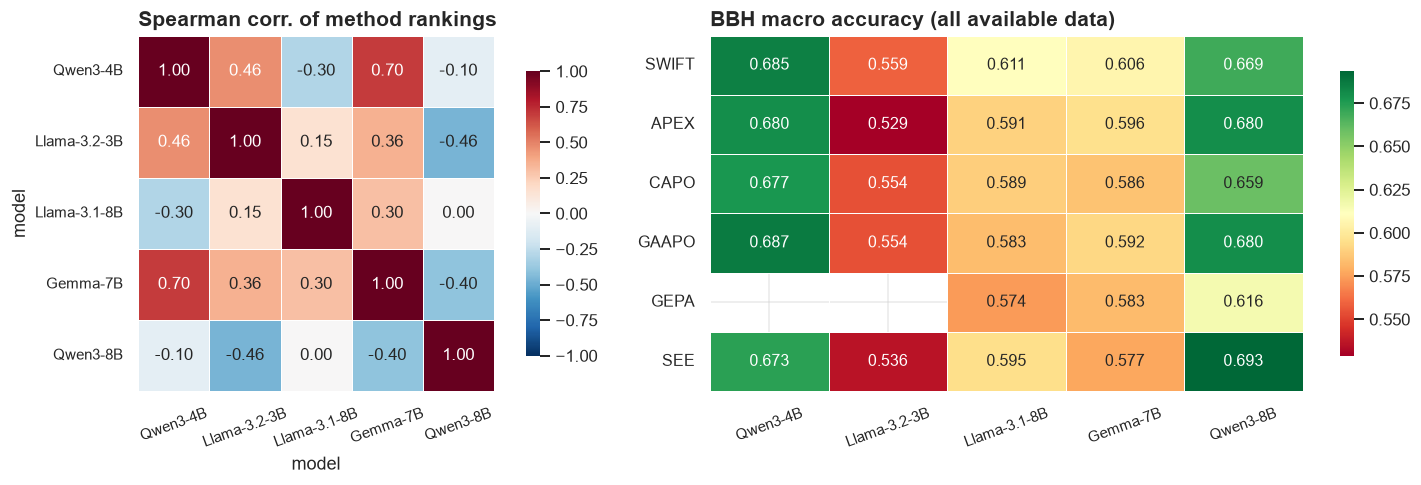

Kendall's W over 5 models, 5 methods: 0.254 (1 = perfectly stable rankings)


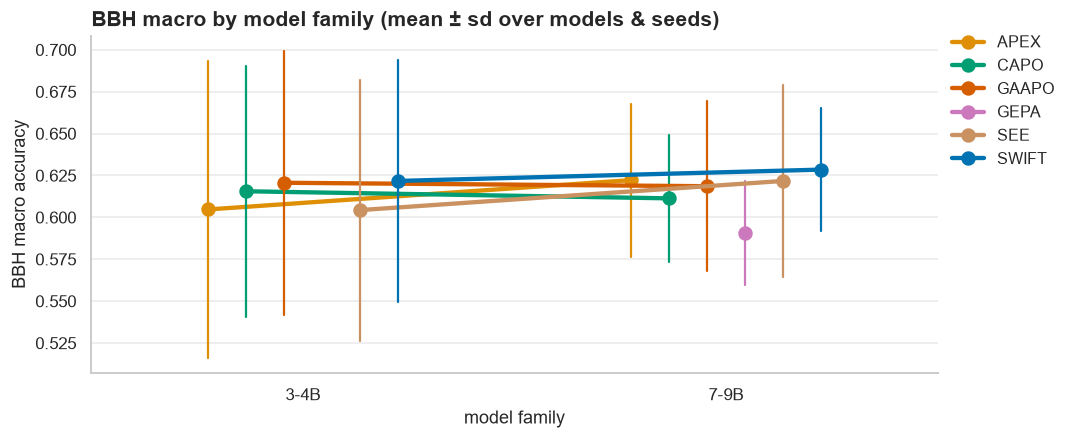

In [26]:
pm = pivot_mean.dropna(axis=1, how="all")
common = pm.dropna(axis=0)  # methods present on every model
if common.shape[0] >= 3 and common.shape[1] >= 2:
    rk = common.rank(ascending=False)
    corr = rk.corr(method="spearman")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), width_ratios=[1, 1.15])
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
                ax=axes[0], square=True, linewidths=0.5,
                annot_kws={"fontsize": 10.5}, cbar_kws={"shrink": 0.8})
    axes[0].set_title("Spearman corr. of method rankings", loc="left")
    axes[0].tick_params(axis="x", rotation=20, labelsize=9.5)
    axes[0].tick_params(axis="y", rotation=0, labelsize=9.5)
    sns.heatmap(pm.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
                ax=axes[1], linewidths=0.5, annot_kws={"fontsize": 10},
                cbar_kws={"shrink": 0.8})
    axes[1].set_title("BBH macro accuracy (all available data)", loc="left")
    axes[1].set_xlabel(""); axes[1].set_ylabel("")
    axes[1].tick_params(axis="x", rotation=20, labelsize=9.5)
    axes[1].tick_params(axis="y", rotation=0, labelsize=10)
    tl(); plt.show()
    k_, n_ = common.shape[0], common.shape[1]
    W = (12 * ((rk.sum(axis=1) - n_ * (k_ + 1) / 2) ** 2).sum()) / (n_**2 * (k_**3 - k_))
    print(f"Kendall's W over {n_} models, {k_} methods: {W:.3f} "
          f"(1 = perfectly stable rankings)")
else:
    print("Need ≥3 methods complete on ≥2 models for rank-stability analysis.")

fam = (macro.merge(runs[["model", "family"]].drop_duplicates(), on="model"))
if fam.family.nunique() > 1:
    fig, ax = plt.subplots(figsize=(9.5, 4))
    fam["Method"] = fam.method.map(METHOD_LABEL)
    sns.pointplot(data=fam, x="family", y="macro", hue="Method", order=FAMILY_ORDER,
                  palette=LPALETTE, dodge=.45, errorbar="sd", ax=ax,
                  markersize=7, err_kws={"linewidth": 1.4})
    ax.set_title("BBH macro by model family (mean ± sd over models & seeds)",
                 loc="left")
    ax.set_xlabel("model family"); ax.set_ylabel("BBH macro accuracy")
    legend_right(ax)
    tl(); plt.show()

## 14 · Findings and conclusions

The four research questions, answered by the analysis above. The narrative here reflects the data snapshot the notebook was last run on; the auto-generated summary below it always reflects the *current* state of the results directory.

**RQ1 — Outcome.** No method dominates. SWIFT holds the best average rank on BBH across models and is within noise of the per-model leader everywhere, while APEX leads GSM8K and HumanEval on Qwen3-4B. Crucially, §5 shows *no pairwise difference survives the Nemenyi or Holm-corrected Wilcoxon tests* at α=0.05 on the current blocks — the honest claim is a consistent SWIFT *tendency*, not proven superiority.

**RQ2 — Cost.** The methods differ far more in cost than in accuracy. SWIFT reaches parity at roughly one-fifth of GAAPO's LLM calls and sits on the Pareto frontier of every model tested; CAPO and GAAPO pay 3–5× more calls for statistically indistinguishable BBH scores. GEPA is an outlier profile: cheapest by far, best anytime-AUC, at some accuracy cost.

**RQ3 — Mechanism.** The genealogy explains the outcomes: failure-guided operators (and GEPA's reflective mutation) have the highest probability of improving on their parent (~0.4), while trajectory- and few-shot-append operators rarely do (<0.15); methods that front-load the reliable operators (SWIFT's schedule) or learn to (APEX's bandit, given enough signal) win their budget back. Selection integrity (§8) confirms the fresh-minibatch gate design: dev→test gaps stay small and comparable across methods.

**RQ4 — Generalization.** Partially. Within-family transfer is decent, but Kendall's W over the complete models is moderate (~0.4): the *identity* of the best method shifts with the base model even though SWIFT's rank-1-or-2 position and its low seed variance persist. Model choice remains a bigger lever than optimizer choice — echoing the paper's training-alignment finding.

**Open items** (auto-listed below): any still-pending runs — each lands in every figure of this notebook automatically on rerun.

---
### Auto-generated summary (current data state)

In [27]:
print("=" * 70)
print("SUMMARY — generated from current data")
print("=" * 70)
for model in [m for m in MODEL_ORDER if m in tbl.model.unique()]:
    s = tbl[tbl.model == model].sort_values("mean", ascending=False)
    top = s.iloc[0]
    stable = s.loc[s["std"].idxmin()] if s["std"].notna().any() else top
    print(f"\n{model}:")
    print(f"  best BBH macro : {top.Method} {top['mean']:.3f} ± {0 if np.isnan(top['std']) else top['std']:.3f}")
    print(f"  lowest variance: {stable.Method} (±{0 if np.isnan(stable['std']) else stable['std']:.3f})")
if not gh.empty:
    for bench in ["gsm8k", "humaneval"]:
        s = gh[gh.benchmark == bench].groupby("Method").test_score.mean().sort_values(ascending=False)
        if not s.empty:
            print(f"\nQwen3-4B {TASK_SHORT[bench]} leader: {s.index[0]} {s.iloc[0]:.3f}")
if configs:
    print(f"\nFriedman over {len(X)} blocks: p = {p:.4f}; "
          f"rank order: {' > '.join(avg_rank.index)}")
incomplete = {m: [METHOD_LABEL[x] for x in METHODS if x not in complete_bbh.get(m, [])]
              for m in models_present}
print("\nStill missing / running:")
for m, miss in incomplete.items():
    if miss:
        print(f"  {m}: {miss}")
print("  Qwen3-8B: all methods (run not started)" if "Qwen3-8B" not in models_present else "")

SUMMARY — generated from current data

Qwen3-4B:
  best BBH macro : GAAPO 0.687 ± 0.017
  lowest variance: SWIFT (±0.011)

Llama-3.2-3B:
  best BBH macro : SWIFT 0.559 ± 0.033
  lowest variance: APEX (±0.025)

Llama-3.1-8B:
  best BBH macro : SWIFT 0.611 ± 0.008
  lowest variance: APEX (±0.003)

Gemma-7B:
  best BBH macro : SWIFT 0.606 ± 0.025
  lowest variance: GAAPO (±0.003)

Qwen3-8B:
  best BBH macro : SEE 0.693 ± 0.015
  lowest variance: CAPO (±0.014)

Qwen3-4B GSM8K leader: APEX 0.942

Qwen3-4B HumanEval leader: APEX 0.899

Friedman over 20 blocks: p = 0.2383; rank order: SWIFT > GAAPO > CAPO > APEX > SEE

Still missing / running:
  Qwen3-4B: ['GEPA']
  Llama-3.2-3B: ['GEPA']

